In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import matplotlib.cm as cm
from matplotlib.widgets import Slider

import warnings
warnings.filterwarnings("ignore")
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

### Toth Model

In [46]:
def toth_model(x, pressure, T):            
    qs_val = x[0] * np.exp(x[1] * (1.0 - (T / T0)))
    b_val  = x[2] * np.exp((-dH / (R * T0)) * ((T0 / T) - 1.0))
    t_val  = x[3] + x[4] * (1.0 - (T0 / T))

    q_star = (qs_val * b_val * pressure)/((1 + (b_val * pressure)**t_val)**(1 / t_val))

    return q_star

def residuals_toth(x, pressure, T, y_Toth):            
    q_pred = toth_model(x, pressure, T)
    return q_pred - y_Toth

In [3]:
# Jung and Lee dry CO2 data
R = 8.314

T0 = 313
dH = -53970

JLdry_co2_pts = pd.read_csv('JLdry_co2pts.csv')

pressures = JLdry_co2_pts['pCO2 (bar)'].values * 100 # to put in kPa
Temps = JLdry_co2_pts['Temp (K)'].values
y_values = JLdry_co2_pts['CO2 Adsorption (mmol/g)'].values

In [4]:
num_starts = 500
best_res = np.inf
best_params = None

# Define physically realistic initialization bounds
# [qs0, chi, b0, t0, alpha]
init_lower = [0.001, -5.0,   0.001, 0.001, -5.0]
init_upper = [20.0,   5.0, 200.0,   1.0,    5.0]


for i in range(num_starts):
    # Pick random starting point
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
        
    try:
    # Run unbounded optimization
        results = least_squares(
            residuals_toth, 
            x0_random, 
            args=(pressures, Temps, y_values),
            method='lm' 
        )
        
        if results.success:
            ssr = sum(results.fun**2)
            
            if ssr < best_res:
                best_res = ssr
                best_params = results.x
                    
    except Exception as e:
         pass


# Print Best Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qs0 (Sat Capacity) : {best_params[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {best_params[1]:.4f}")
print(f"b0 (Affinity)      : {best_params[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {best_params[3]:.4f}")
print(f"alpha (Temp dep t) : {best_params[4]:.4f}")

Global Best SSR: 0.152358
qs0 (Sat Capacity) : 3.3284 mmol/g
chi (Temp dep qs)  : -3.0860
b0 (Affinity)      : 76.0450 kPa-1
t0 (Heterogeneity) : 0.3436
alpha (Temp dep t) : -1.2471


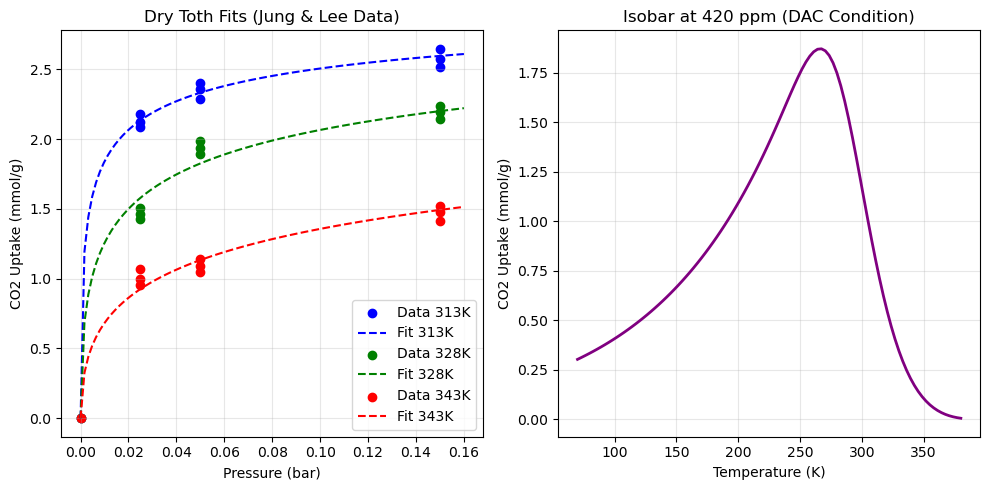

In [5]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
colors = {313: 'blue', 328: 'green', 343: 'red'}
p_bar = np.linspace(0, 0.16, 100)
p_kPa = p_bar * 100

# Plot 1: Isotherms
for T_val in [313, 328, 343]:
    subset = JLdry_co2_pts[JLdry_co2_pts['Temp (K)'] == T_val]
    axs[0].scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=colors[T_val], label=f'Data {T_val}K')
    
    q_pred_curve = toth_model(best_params, p_kPa, T_val)
    axs[0].plot(p_bar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('Pressure (bar)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('Dry Toth Fits (Jung & Lee Data)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Isobar at 420 ppm (0.042 kPa)
T_range = np.linspace(70, 380, 100)
q_dac = toth_model(best_params, pressure=0.042, T=T_range)

axs[1].plot(T_range, q_dac, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('Isobar at 420 ppm (DAC Condition)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

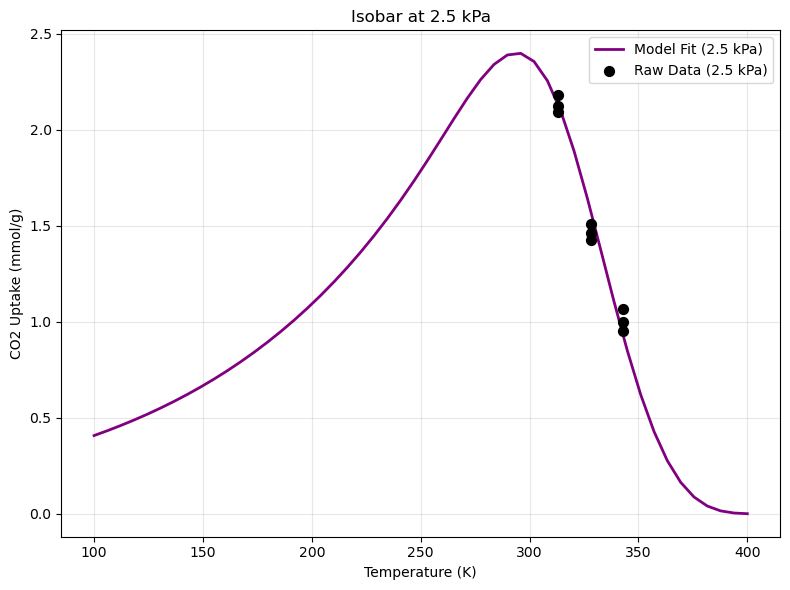

In [6]:
# Test Isobar on raw data:
subset_2_5kPa = JLdry_co2_pts[np.isclose(JLdry_co2_pts['pCO2 (bar)'].values * 100, 2.5)]

T_range = np.linspace(100, 400, 50)
q_sim = toth_model(best_params, pressure=2.5, T=T_range)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(T_range, q_sim, color='purple', linewidth=2, label='Model Fit (2.5 kPa)')

ax.scatter(subset_2_5kPa['Temp (K)'], subset_2_5kPa['CO2 Adsorption (mmol/g)'], 
           color='black', s=50, zorder=5, label='Raw Data (2.5 kPa)')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('CO2 Uptake (mmol/g)')
ax.set_title('Isobar at 2.5 kPa')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
num_starts = 500
best_res = np.inf
best_params = None

# Realistic initialization bounds
# [qs0, chi, b0, t0, alpha]
init_lower = [1, -5, 0.001, 0.001,   -5.0]
init_upper = [5,  5,   200,   1.0,    5.0]

# Solver bounds
solver_lower = [1, -5, 1e-8,  1e-5, -5]
solver_upper = [5,  5,  200,   1.0,  5]


for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    
    try:
        results = least_squares(
            residuals_toth, 
            x0_random, 
            args=(pressures, Temps, y_values),
            bounds=(solver_lower, solver_upper),
            method='trf' 
        )
        
        if results.success:
            ssr = sum(results.fun**2)
            
            if ssr < best_res:
                best_res = ssr
                best_params = results.x
                
    except Exception as e:
        pass


# Print Best Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qs0 (Sat Capacity) : {best_params[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {best_params[1]:.4f}")
print(f"b0 (Affinity)      : {best_params[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {best_params[3]:.4f}")
print(f"alpha (Temp dep t) : {best_params[4]:.4f}")

Global Best SSR: 0.152358
qs0 (Sat Capacity) : 3.3284 mmol/g
chi (Temp dep qs)  : -3.0860
b0 (Affinity)      : 76.0450 kPa-1
t0 (Heterogeneity) : 0.3436
alpha (Temp dep t) : -1.2471


In [8]:
# Wang and Chen dry CO2 data
R = 8.314

T0 = 323.15 # K
dH = -119600 # Joules (∆H)

WC_co2 = pd.read_csv('WangChen_co2.csv')

pressures = WC_co2['pCO2 (kPa)'].values # kPa
Temps = WC_co2['Temp (K)'].values
y_values = WC_co2['CO2 Adsorption (mmol/g)'].values

In [9]:
num_starts = 500
best_res = np.inf
best_params = None

# Define physically realistic initialization bounds
# [qs0, chi, b0, t0, alpha]
init_lower = [0.001, -5.0,   0.001, 0.001, -5.0]
init_upper = [20.0,   5.0, 200.0,   1.0,    5.0]


for i in range(num_starts):
    # Pick random starting point
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
        
    try:
    # Run unbounded optimization
        results = least_squares(
            residuals_toth, 
            x0_random, 
            args=(pressures, Temps, y_values),
            method='lm' 
        )
        
        if results.success:
            ssr = sum(results.fun**2)
            
            if ssr < best_res:
                best_res = ssr
                best_params = results.x
                    
    except Exception as e:
         pass


# Print Best Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qs0 (Sat Capacity) : {best_params[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {best_params[1]:.4f}")
print(f"b0 (Affinity)      : {best_params[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {best_params[3]:.4f}")
print(f"alpha (Temp dep t) : {best_params[4]:.4f}")

Global Best SSR: 0.014880
qs0 (Sat Capacity) : 0.8934 mmol/g
chi (Temp dep qs)  : -4.3208
b0 (Affinity)      : 57.9354 kPa-1
t0 (Heterogeneity) : 0.5820
alpha (Temp dep t) : 1.5952


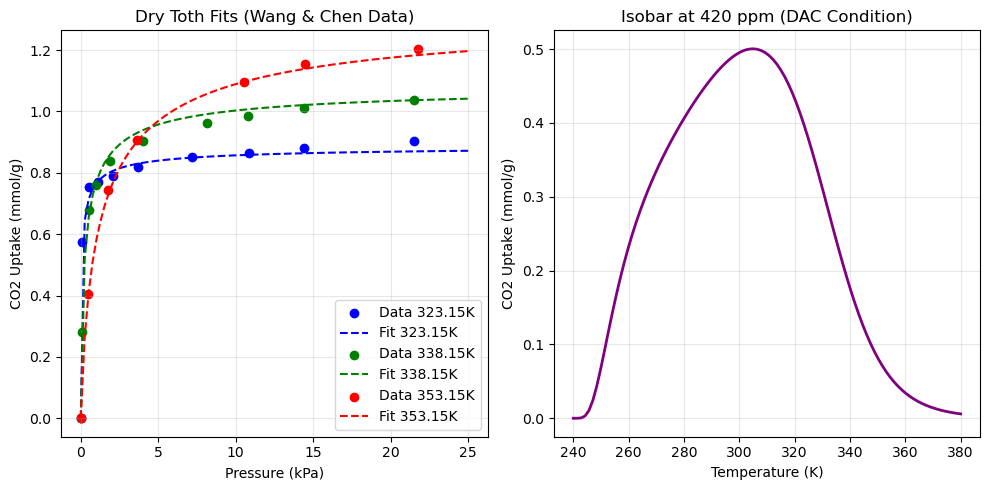

In [10]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
colors = {323.15: 'blue', 338.15: 'green', 353.15: 'red'}
p_kPa = np.linspace(0, 25, 100)

# Plot 1: Isotherms
for T_val in [323.15, 338.15, 353.15]:
    subset = WC_co2[WC_co2['Temp (K)'] == T_val]
    axs[0].scatter(subset['pCO2 (kPa)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=colors[T_val], label=f'Data {T_val}K')
    
    q_pred_curve = toth_model(best_params, p_kPa, T_val)
    axs[0].plot(p_kPa, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('Pressure (kPa)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('Dry Toth Fits (Wang & Chen Data)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Isobar at 420 ppm (0.042 kPa)
T_range = np.linspace(240, 380, 100)
q_dac = toth_model(best_params, pressure=0.042, T=T_range)

axs[1].plot(T_range, q_dac, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('Isobar at 420 ppm (DAC Condition)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

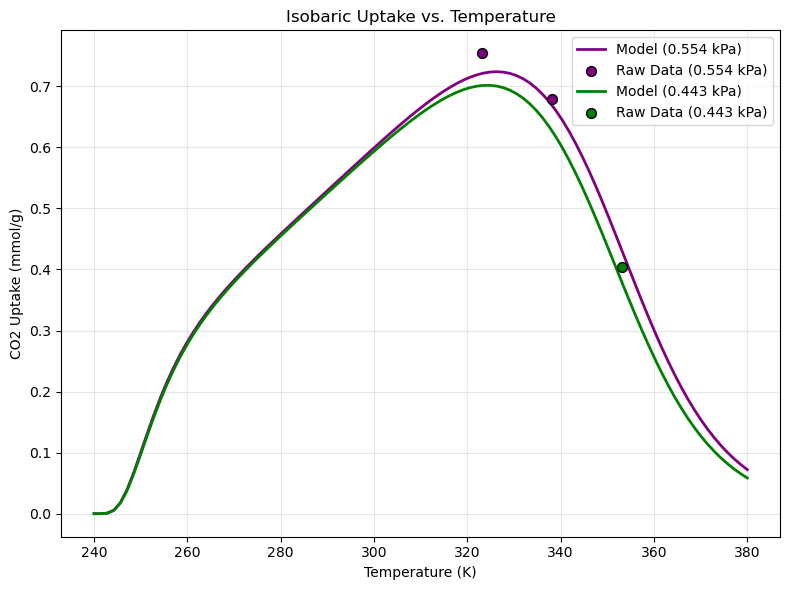

In [11]:
# Test Isobar on raw data:
pressures_to_check = [0.554, 0.443]

colors = ['purple', 'green'] 

fig, ax = plt.subplots(figsize=(8, 6))
T_range = np.linspace(240, 380, 100)

for i, P_target in enumerate(pressures_to_check):
    c = colors[i % len(colors)]
    
    q_sim = toth_model(best_params, pressure=P_target, T=T_range)
    ax.plot(T_range, q_sim, color=c, linewidth=2, label=f'Model ({P_target} kPa)')
    
    subset = WC_co2[np.isclose(WC_co2['pCO2 (kPa)'].values, P_target, atol=0.01)]
    
    ax.scatter(subset['Temp (K)'], subset['CO2 Adsorption (mmol/g)'], 
               color=c, s=50, edgecolor='black', zorder=5, 
               label=f'Raw Data ({P_target} kPa)')

ax.set_xlabel('Temperature (K)')
ax.set_ylabel('CO2 Uptake (mmol/g)')
ax.set_title('Isobaric Uptake vs. Temperature')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
# Liu dry CO2 data
R = 8.314

T0 = 298.15 # K
dH = -84000 # Joules (∆H)

Liu_co2 = pd.read_csv('Liu_dryCO2_pts.csv')

pressures = Liu_co2['pCO2 (atm)'].values * 101.325 # atm to kPa
Temps = Liu_co2['Temp (K)'].values
y_values = Liu_co2['CO2 Adsorption (mmol/g)'].values

In [51]:
num_starts = 500
best_res = np.inf
best_params = None

# Define physically realistic initialization bounds
# [qs0, chi, b0, t0, alpha]
init_lower = [0.001, -5.0,   0.001, 0.001, -5.0]
init_upper = [20.0,   5.0, 200.0,   1.0,    5.0]


for i in range(num_starts):
    # Pick random starting point
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
        
    try:
    # Run unbounded optimization
        results = least_squares(
            residuals_toth, 
            x0_random, 
            args=(pressures, Temps, y_values),
            method='lm' 
        )
        
        if results.success:
            ssr = sum(results.fun**2)
            
            if ssr < best_res:
                best_res = ssr
                best_params = results.x
                    
    except Exception as e:
         pass


# Print Best Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qs0 (Sat Capacity) : {best_params[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {best_params[1]:.4f}")
print(f"b0 (Affinity)      : {best_params[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {best_params[3]:.4f}")
print(f"alpha (Temp dep t) : {best_params[4]:.4f}")

Global Best SSR: 0.002030
qs0 (Sat Capacity) : 1.1493 mmol/g
chi (Temp dep qs)  : -4.1215
b0 (Affinity)      : 55020.9968 kPa-1
t0 (Heterogeneity) : 0.1701
alpha (Temp dep t) : -0.2452


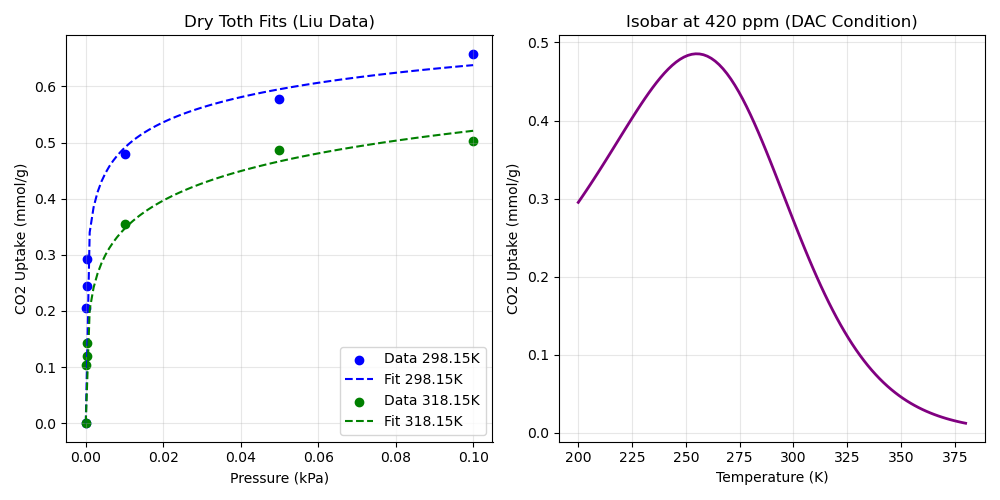

In [56]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
colors = {298.15: 'blue', 318.15: 'green'}
p_atm = np.linspace(0, 0.1, 100)
p_kPa = p_atm * 101.325

# Plot 1: Isotherms
for T_val in [298.15, 318.15]:
    # Raw data points
    subset = Liu_co2[Liu_co2['Temp (K)'] == T_val]
    axs[0].scatter(subset['pCO2 (atm)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')

    # Fitted curve
    q_pred_curve = toth_model(best_params, p_kPa, T_val)
    axs[0].plot(p_atm, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('Pressure (kPa)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('Dry Toth Fits (Liu Data)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Isobar at 420 ppm (0.042 kPa)
T_range = np.linspace(200, 380, 100)
q_dac = toth_model(best_params, pressure=0.042, T=T_range)

axs[1].plot(T_range, q_dac, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('Isobar at 420 ppm (DAC Condition)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### GAB Fitting

In [57]:
# Calculate RH Using Clausius-Clapeyron
def get_RH(Temp,pH2O_kPa):
    Ps_Pa = 611.3 * np.exp(5417.1 * (1 / 273.15 - 1 / Temp))
    RH = (pH2O_kPa*1000) / Ps_Pa 
    return RH

def GAB_model(x, RH, T):
    C = x[1] * np.exp(-dH_C / (R * T))
    K = x[2] * np.exp(-dH_K / (R * T))
    
    numerator = x[0] * C * K * RH
    denom = (1 - K * RH) * (1 + (C - 1) * K * RH)
    
    return numerator / denom

def residuals_GAB(x, RH, T, y_GAB):            
    q_h2o = GAB_model(x, RH, T)
    return q_h2o - y_GAB

def GAB_model_fit_dH(x, RH, T):
    q_m  = x[0]
    C0   = x[1]
    K0   = x[2]
    dH_C = x[3]
    dH_K = x[4]

    C = C0 * np.exp(-dH_C / (R * T))
    K = K0 * np.exp(-dH_K / (R * T))
    
    numerator = q_m * C * K * RH
    denom = (1 - K * RH) * (1 + (C - 1) * K * RH)
    
    return numerator / denom

def residuals_GAB_fit_dH(x, RH, T, y_GAB):            
    q_h2o = GAB_model_fit_dH(x, RH, T)
    return q_h2o - y_GAB

def GAB_model_fit_dH_C(x, RH, T):
    q_m  = x[0]
    C0   = x[1]
    K0   = x[2]
    dH_C = x[3]

    C = C0 * np.exp(-dH_C / (R * T))
    K = K0 * np.exp(-dH_K / (R * T))
    
    numerator = q_m * C * K * RH
    denom = (1 - K * RH) * (1 + (C - 1) * K * RH)
    
    return numerator / denom

def residuals_GAB_fit_dH_C(x, RH, T, y_GAB):            
    q_h2o = GAB_model_fit_dH_C(x, RH, T)
    return q_h2o - y_GAB

def GAB_model_fit_dH_K(x, RH, T):
    q_m  = x[0]
    C0   = x[1]
    K0   = x[2]
    dH_K = x[3]

    # dH_C is fixed/global
    C = C0 * np.exp(-dH_C / (R * T))
    K = K0 * np.exp(-dH_K / (R * T))

    numerator = q_m * C * K * RH
    denom = (1 - K * RH) * (1 + (C - 1) * K * RH)

    return numerator / denom


def residuals_GAB_fit_dH_K(x, RH, T, y_GAB):
    q_h2o = GAB_model_fit_dH_K(x, RH, T)
    return q_h2o - y_GAB

In [114]:
# Jung and Lee H2O data
gab_h2o = pd.read_csv('JL_h2o_pts.csv')
T_values = [313, 328, 343]

pressures_h2o = gab_h2o['pH2O (bar)'].values * 100
Temps_h2o = gab_h2o['Temp (K)'].values
y_h2o = gab_h2o['Adsorption (mmol/g)'].values
RH_array = get_RH(Temps_h2o, pressures_h2o)

In [14]:
num_starts = 500
best_res_roam = np.inf
best_params_roam = None

# Fit both ∆H_C and ∆H_K
# [qm, C0, kG0, dH_C, dH_K]
lower_roam = [1.0, 1e-16, 1e-2, -90000, -10000]
upper_roam = [5.0, 1e-4, 5, -30000, 10000]

for i in range(num_starts):
    x0 = np.random.uniform(low=lower_roam, high=upper_roam)
    try:
        res = least_squares(residuals_GAB_fit_dH, x0, args=(RH_array, Temps_h2o, y_h2o),
                            bounds=(lower_roam, upper_roam), method='trf')
        if res.success and sum(res.fun**2) < best_res_roam:
            best_res_roam, best_params_roam = sum(res.fun**2), res.x
    except: pass

# Fit just ∆H_C
dH_K = -100 # Fixed constant

best_res_fix = np.inf
best_params_fix = None

# [qm, C0, kG0, dH_C]
lower_fix = [1.0, 1e-16, 1e-2, -90000]
upper_fix = [5.0, 1e-4, 5, -30000]

for i in range(num_starts):
    x0 = np.random.uniform(low=lower_fix, high=upper_fix)
    try:
        res = least_squares(residuals_GAB_fit_dH_C, x0, args=(RH_array, Temps_h2o, y_h2o),
                            bounds=(lower_fix, upper_fix), method='trf')
        if res.success and sum(res.fun**2) < best_res_fix:
            best_res_fix, best_params_fix = sum(res.fun**2), res.x
    except: pass

# Print results of both
print("\n Scenario 1 Results")
print(f"SSR: {best_res_roam:.4f}")
print(f"qm: {best_params_roam[0]:.4f}")
print(f"C0: {best_params_roam[1]:.4e}")
print(f"kG0: {best_params_roam[2]:.4e}")
print(f"dH_C: {best_params_roam[3]:.0f}")
print(f"dH_K: {best_params_roam[4]:.0f}")

for T in [313, 328, 343]:
    C_r = best_params_roam[1] * np.exp(-best_params_roam[3] / (R * T))
    K_r = best_params_roam[2] * np.exp(-best_params_roam[4] / (R * T))
    print(f"T = {T} K  ->  C = {C_r:.4f}  |  K = {K_r:.4f}")

print("\n Scenario 2 Results")
print(f"SSR: {best_res_fix:.4f}")
print(f"qm: {best_params_fix[0]:.4f}")
print(f"C0: {best_params_fix[1]:.4e}")
print(f"kG0: {best_params_fix[2]:.4f}")
print(f"dH_C: {best_params_fix[3]:.0f}")

for T in [313, 328, 343]:
    C_f = best_params_fix[1] * np.exp(-best_params_fix[3] / (R * T))
    K_f = best_params_fix[2] * np.exp(-0 / (R * T))
    print(f"T = {T} K  ->  C = {C_f:.4f}  |  K = {K_f:.4f}")



 Scenario 1 Results
SSR: 0.0559
qm: 3.9327
C0: 6.7927e-08
kG0: 1.0205e-02
dH_C: -54168
dH_K: -2099
T = 313 K  ->  C = 74.4845  |  K = 0.0229
T = 328 K  ->  C = 28.7508  |  K = 0.0220
T = 343 K  ->  C = 12.0613  |  K = 0.0213

 Scenario 2 Results
SSR: 0.0571
qm: 4.1044
C0: 1.0358e-07
kG0: 0.0112
dH_C: -54670
T = 313 K  ->  C = 137.7545  |  K = 0.0112
T = 328 K  ->  C = 52.7056  |  K = 0.0112
T = 343 K  ->  C = 21.9332  |  K = 0.0112


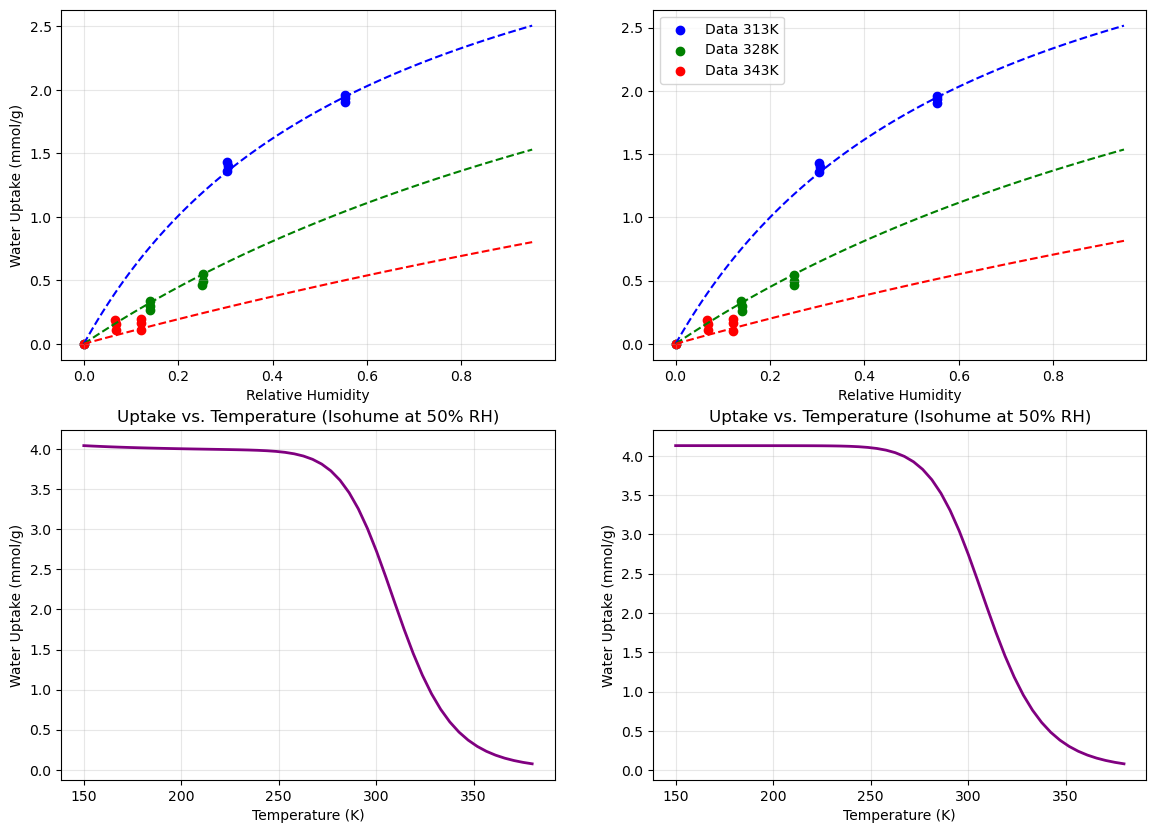

In [15]:
# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()
colors = {313: 'blue', 328: 'green', 343: 'red'}
RH_plot = np.linspace(0, 0.95, 100)

for T_val in T_values:
    subset = gab_h2o[gab_h2o['Temp (K)'] == T_val]
    RH_sub = get_RH(T_val, subset['pH2O (bar)'].values * 100)
    
    # Plot Data on both
    axs[0].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val}K')
    axs[1].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val}K')
    
    T_plot = np.full_like(RH_plot, T_val)
    
    # First curve
    q_pred_A = GAB_model_fit_dH(best_params_roam, RH_plot, T_plot)
    axs[0].plot(RH_plot, q_pred_A, '--', color=colors[T_val])
    
    # Second curve
    q_pred_B = GAB_model_fit_dH_C(best_params_fix, RH_plot, T_plot)
    axs[1].plot(RH_plot, q_pred_B, '--', color=colors[T_val])

axs[0].set_xlabel('Relative Humidity')
axs[0].set_ylabel('Water Uptake (mmol/g)')
axs[0].grid(True, alpha=0.3)

axs[1].set_xlabel('Relative Humidity')
axs[1].grid(True, alpha=0.3)
axs[1].legend()

# Plot 2: Uptake vs Temperature at 50% RH
T_range = np.linspace(150, 380, 50)
RH_constant = np.full_like(T_range, 0.50)
q_temp_decay = GAB_model_fit_dH(best_params_roam, RH_constant, T_range)

axs[2].plot(T_range, q_temp_decay, color='purple', linewidth=2)
axs[2].set_xlabel('Temperature (K)')
axs[2].set_ylabel('Water Uptake (mmol/g)')
axs[2].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[2].grid(True, alpha=0.3)

q_temp_decay1 = GAB_model_fit_dH_C(best_params_fix, RH_constant, T_range)

axs[3].plot(T_range, q_temp_decay1, color='purple', linewidth=2)
axs[3].set_xlabel('Temperature (K)')
axs[3].set_ylabel('Water Uptake (mmol/g)')
axs[3].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[3].grid(True, alpha=0.3)

plt.show()

In [16]:
# Try fitting with both ∆H_C and ∆H_K fixed
dH_C = -57210
dH_K_tests = [1000, 0, -1000]
num_starts = 500

# Bounds: [qm, C0, kG0]
init_lower = [0.1,  1e-12, 0.1]
init_upper = [5.0, 1.0,   1.0]

solver_lower = [0.001, 1e-16, 0.05]
solver_upper = [5.0,  1.0,  5.0]

for dH_K_test in dH_K_tests:
    dH_K = dH_K_test
    
    best_res = np.inf
    best_params = None
    
    for i in range(num_starts):
        x0 = np.random.uniform(low=init_lower, high=init_upper)
        try:
            res = least_squares(
                residuals_GAB, x0, 
                args=(RH_array, Temps_h2o, y_h2o),
                bounds=(solver_lower, solver_upper), method='trf'
            )
            if res.success and sum(res.fun**2) < best_res:
                best_res = sum(res.fun**2)
                best_params = res.x
        except: pass
        
    print(f"dH_K = {dH_K_test} J/mol")
    print(f"   SSR: {best_res:.4f}")
    print(f"   qm : {best_params[0]:.4f} mmol/g")
    print(f"   C0 : {best_params[1]:.4e}")
    print(f"   kG0: {best_params[2]:.4f}")
    
    for T in T_values:
        C = best_params[1] * np.exp(-dH_C/ (R * T))
        K = best_params[2] * np.exp(-dH_K_test / (R * T))
        print(f"      T={T}K -> C = {C:.2f} | K = {K:.4f}")
    print("-" * 50)

dH_K = 1000 J/mol
   SSR: 0.0636
   qm : 3.4048 mmol/g
   C0 : 4.3156e-09
   kG0: 0.1857
      T=313K -> C = 15.23 | K = 0.1265
      T=328K -> C = 5.57 | K = 0.1287
      T=343K -> C = 2.23 | K = 0.1308
--------------------------------------------------
dH_K = 0 J/mol
   SSR: 0.0609
   qm : 3.4131 mmol/g
   C0 : 4.8987e-09
   kG0: 0.1132
      T=313K -> C = 17.29 | K = 0.1132
      T=328K -> C = 6.33 | K = 0.1132
      T=343K -> C = 2.53 | K = 0.1132
--------------------------------------------------
dH_K = -1000 J/mol
   SSR: 0.0583
   qm : 3.4445 mmol/g
   C0 : 5.8635e-09
   kG0: 0.0650
      T=313K -> C = 20.70 | K = 0.0954
      T=328K -> C = 7.57 | K = 0.0938
      T=343K -> C = 3.03 | K = 0.0923
--------------------------------------------------


In [17]:
# Fit just ∆H_K
dH_C = -57210

num_starts = 500
best_res_fix = np.inf
best_params_fixC = None

# [qm, C0, K0, dH_K]
lower_fix = [1.0, 1e-14, 0.05, -10000]
upper_fix = [5.0, 1.0, 5, 5000]

for i in range(num_starts):
    x0 = np.random.uniform(low=lower_fix, high=upper_fix)

    try:
        res = least_squares(
            residuals_GAB_fit_dH_K,
            x0,
            args=(RH_array, Temps_h2o, y_h2o),
            bounds=(lower_fix, upper_fix),
            method='trf'
        )

        if res.success and np.sum(res.fun**2) < best_res_fix:
            best_res_fix = np.sum(res.fun**2)
            best_params_fixC = res.x

    except:
        pass

print("\n Scenario 3 Results")
print(f"SSR: {best_res_fix:.4f}")
print(f"qm: {best_params_fixC[0]:.4f}")
print(f"C0: {best_params_fixC[1]:.4e}")
print(f"kG0: {best_params_fixC[2]:.4f}")
print(f"dH_K: {best_params_fixC[3]:.0f}")

for T in [313, 328, 343]:
    C_f = best_params_fixC[1] * np.exp(-dH_C / (R * T))
    K_f = best_params_fixC[2] * np.exp(-best_params_fixC[3] / (R * T))

    print(f"T = {T} K  ->  C = {C_f:.4f}  |  K = {K_f:.4f}")


 Scenario 3 Results
SSR: 0.0574
qm: 3.4591
C0: 6.4276e-09
kG0: 0.0500
dH_K: -1453
T = 313 K  ->  C = 22.6890  |  K = 0.0874
T = 328 K  ->  C = 8.3019  |  K = 0.0852
T = 343 K  ->  C = 3.3169  |  K = 0.0832


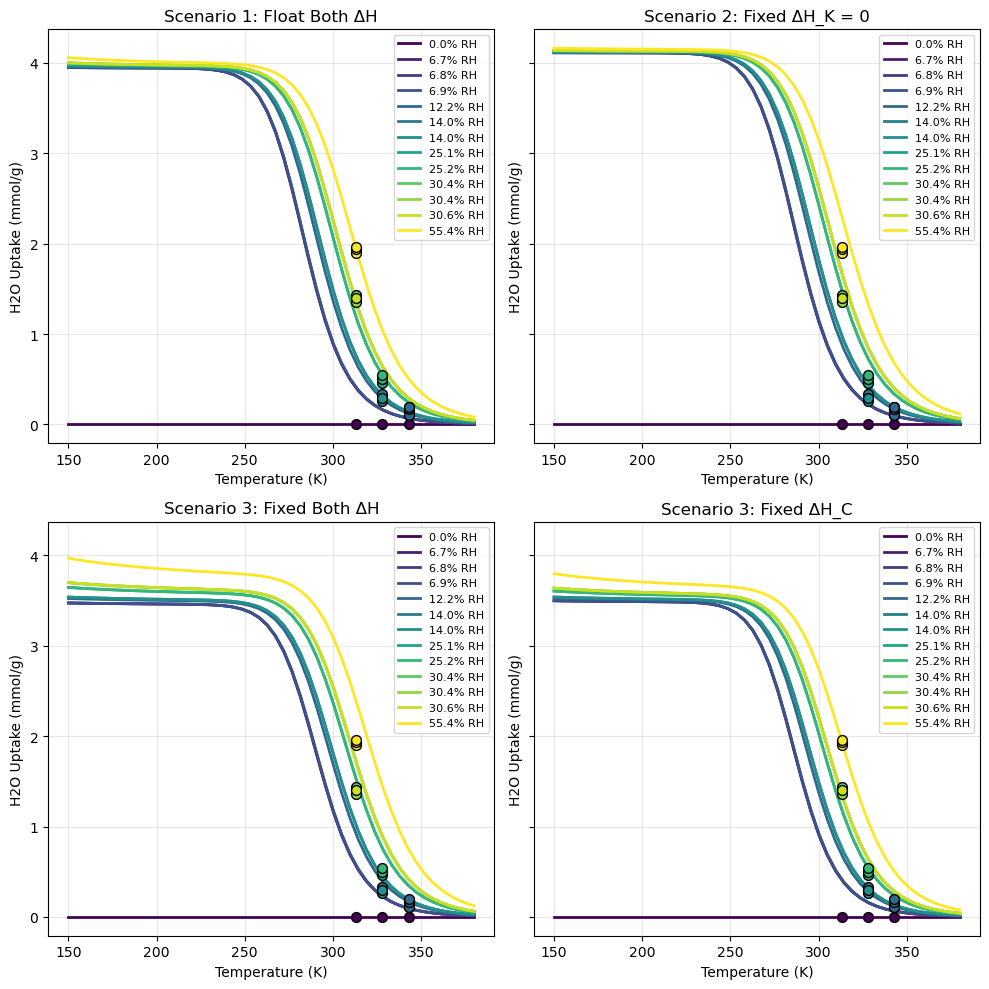

In [18]:
# Compare fits against raw data
gab_h2o['RH'] = get_RH(Temps_h2o, pressures_h2o)
gab_h2o['RH_rounded'] = gab_h2o['RH'].round(4)

unique_rhs = sorted(gab_h2o['RH_rounded'].unique())

fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
axs = axs.flatten()

# params1 = [3.9766, 7.5807e-8, 1.0607e-2, -54221, -1615]
# params2 = [4.1028, 1.0194e-7, 1.1240e-2, -54700]
# params3 = [3.4131, 4.8987e-9, 1.132e-1]
# params4 = [3.8696, 2.0675e-6, 1.0081e-4, -2347]

params1 = best_params_roam
params2 = best_params_fix
params3 = [3.4131, 4.8987e-9, 1.132e-1]
params4 = best_params_fixC

scenarios = [
    ("Scenario 1: Float Both \u0394H", GAB_model_fit_dH, params1),
    ("Scenario 2: Fixed \u0394H_K = 0", GAB_model_fit_dH_C, params2),
    ("Scenario 3: Fixed Both \u0394H", GAB_model, params3),
    ("Scenario 3: Fixed \u0394H_C", GAB_model_fit_dH_K, params4)
]

color_map = cm.get_cmap('viridis', len(unique_rhs))

for col, (title, func, params) in enumerate(scenarios):
    ax = axs[col]
    
    for idx, rh_val in enumerate(unique_rhs):
        c = color_map(idx)
        
        # Plot Model Isohume
        rh_array = np.full_like(T_range, rh_val)
        q_sim = func(params, rh_array, T_range)
        ax.plot(T_range, q_sim, color=c, linewidth=2, label=f'{rh_val*100:.1f}% RH')
        
        # Plot matching raw data
        subset = gab_h2o[gab_h2o['RH_rounded'] == rh_val]
        ax.scatter(subset['Temp (K)'], subset['Adsorption (mmol/g)'], 
                   color=c, s=50, edgecolor='black', zorder=5)

    ax.set_title(title)
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('H2O Uptake (mmol/g)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [19]:
# Wang and Chen H2O data
gab_h2o = pd.read_csv('WangChen_h2o.csv')

dH_L = 43600  
dH_C = -84848 + dH_L # -41248 J/mol
dH_K = -44696 + dH_L # -1096 J/mol

T_values = [323.15, 338.15, 353.15]

pressures_h2o = gab_h2o['pH2O (kPa)'].values
Temps_h2o = gab_h2o['Temp (K)'].values
y_h2o = gab_h2o['Adsorption (mmol/g)'].values
RH_array = get_RH(Temps_h2o, pressures_h2o)

In [20]:
num_starts = 500
best_res = np.inf
best_params = None

# Define physically realistic initialization bounds
# [qm, C0, kG0]
init_lower = [0.5,  1e-7, 0.01]
init_upper = [10.0, 1e-2, 0.9]

# Bounds for the solver
solver_lower = [0.001, 1e-10, 1e-6]
solver_upper = [30.0,  1.0,   0.99]

for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    
    try:
        res = least_squares(
            residuals_GAB, 
            x0_random, 
            args=(RH_array, Temps_h2o, y_h2o),
            bounds=(solver_lower, solver_upper),
            method='trf'
        )
        
        if res.success:
            ssr = sum(res.fun**2)
            if ssr < best_res:
                best_res = ssr
                best_params = res.x
                
    except Exception as e:
        pass


# Print Results
print(f"Global Best SSR: {best_res:.6f}")
print(f"qm (Monolayer Capacity): {best_params[0]:.4f} mmol/g")
print(f"C0 (Monolayer Pre-exp) : {best_params[1]:.4e}")
print(f"kG0(Multilayer Pre-exp): {best_params[2]:.4e}\n")

for T in T_values:
    C_T = best_params[1] * np.exp(-dH_C / (R * T))
    K_T = best_params[2] * np.exp(-dH_K / (R * T))
    print(f"T = {T} K  ->  C = {C_T:.4f}  |  K = {K_T:.4f}")

Global Best SSR: 3.052470
qm (Monolayer Capacity): 3.0555 mmol/g
C0 (Monolayer Pre-exp) : 4.2092e-06
kG0(Multilayer Pre-exp): 6.0860e-01

T = 323.15 K  ->  C = 19.5816  |  K = 0.9152
T = 338.15 K  ->  C = 9.9101  |  K = 0.8987
T = 353.15 K  ->  C = 5.3141  |  K = 0.8840


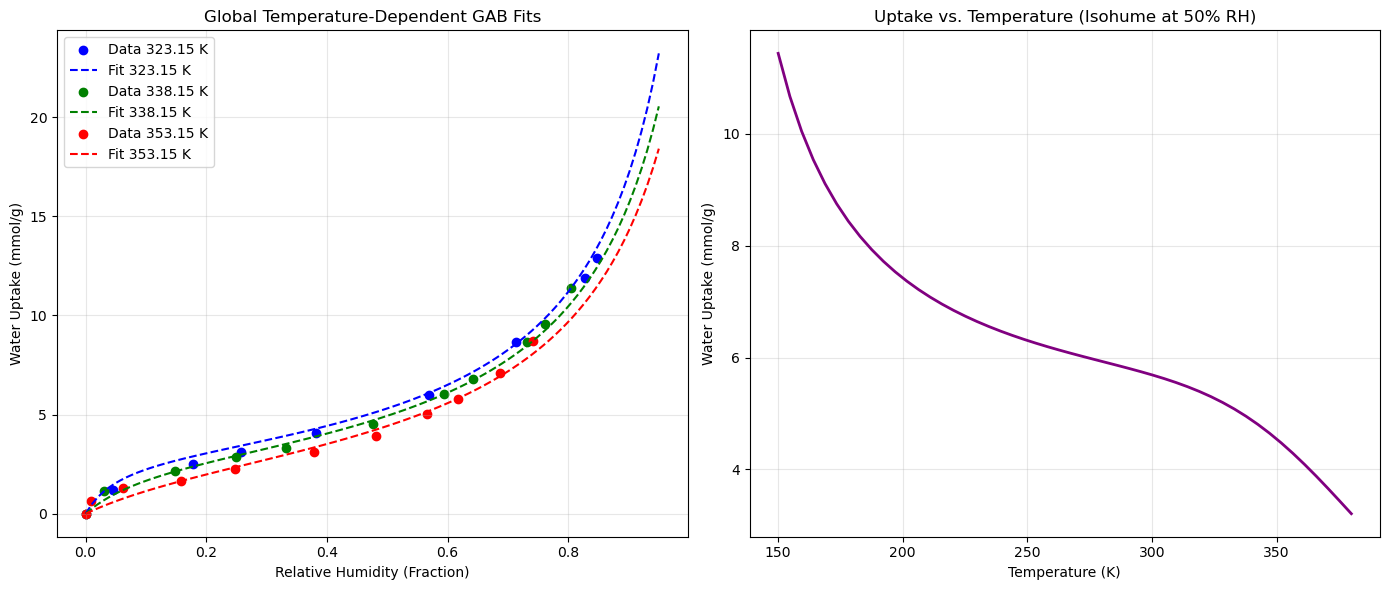

In [21]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
colors = {323.15: 'blue', 338.15: 'green', 353.15: 'red'}

# Plot 1: Isotherms
RH_plot = np.linspace(0, 0.95, 100)

for T_val in T_values:
    subset = gab_h2o[gab_h2o['Temp (K)'] == T_val]
    RH_sub = get_RH(T_val, subset['pH2O (kPa)'].values)
    axs[0].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val} K')
    
    T_plot = np.full_like(RH_plot, T_val)
    q_pred = GAB_model(best_params, RH_plot, T_plot)
    axs[0].plot(RH_plot, q_pred, '--', color=colors[T_val], label=f'Fit {T_val} K')

axs[0].set_xlabel('Relative Humidity (Fraction)')
axs[0].set_ylabel('Water Uptake (mmol/g)')
axs[0].set_title('Global Temperature-Dependent GAB Fits')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Uptake vs Temperature at 50% RH
T_range = np.linspace(150, 380, 50)
RH_constant = np.full_like(T_range, 0.50)
q_temp_decay = GAB_model(best_params, RH_constant, T_range)

axs[1].plot(T_range, q_temp_decay, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('Water Uptake (mmol/g)')
axs[1].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [116]:
# Liu H2O data
gab_h2o = pd.read_csv('Liu_h2o_pts.csv')

T_values = [308.15]

Temps_h2o = gab_h2o['Temp (K)'].values
y_h2o = gab_h2o['Adsorption (mmol/g)'].values
RH_array = gab_h2o['RH'].values

In [103]:
num_starts = 500
best_res_roam = np.inf
best_params_roam = None

# Fit both ∆H_C and ∆H_K
# [qm, C0, kG0, dH_C, dH_K]
lower_roam = [0.1, 1e-20, 1e-6, -90000, -10000]
upper_roam = [50.0, 1e-6, 1, -50000, 10000]

for i in range(num_starts):
    x0 = np.random.uniform(low=lower_roam, high=upper_roam)
    try:
        res = least_squares(residuals_GAB_fit_dH, x0, args=(RH_array, Temps_h2o, y_h2o),
                            bounds=(lower_roam, upper_roam), method='trf')
        if res.success and sum(res.fun**2) < best_res_roam:
            best_res_roam, best_params_roam = sum(res.fun**2), res.x
    except: pass

# Fit just ∆H_C
dH_K = -100 # Fixed constant

best_res_fix = np.inf
best_params_fix = None

# [qm, C0, kG0, dH_C]
lower_fix = [0.1, 1e-20, 1e-6, -90000]
upper_fix = [50.0, 1e-6, 1, -50000]

for i in range(num_starts):
    x0 = np.random.uniform(low=lower_fix, high=upper_fix)
    try:
        res = least_squares(residuals_GAB_fit_dH_C, x0, args=(RH_array, Temps_h2o, y_h2o),
                            bounds=(lower_fix, upper_fix), method='trf')
        if res.success and sum(res.fun**2) < best_res_fix:
            best_res_fix, best_params_fix = sum(res.fun**2), res.x
    except: pass

# Print results of both
print("\n Scenario 1 Results")
print(f"SSR: {best_res_roam:.4f}")
print(f"qm: {best_params_roam[0]:.4f}")
print(f"C0: {best_params_roam[1]:.4e}")
print(f"kG0: {best_params_roam[2]:.4f}")
print(f"dH_C: {best_params_roam[3]:.0f}")
print(f"dH_K: {best_params_roam[4]:.0f}")

for T in [308.15]:
    C_r = best_params_roam[1] * np.exp(-best_params_roam[3] / (R * T))
    K_r = best_params_roam[2] * np.exp(-best_params_roam[4] / (R * T))
    print(f"T = {T} K  ->  C = {C_r:.4f}  |  K = {K_r:.4f}")

print("\n Scenario 2 Results")
print(f"SSR: {best_res_fix:.4f}")
print(f"qm: {best_params_fix[0]:.4f}")
print(f"C0: {best_params_fix[1]:.4e}")
print(f"kG0: {best_params_fix[2]:.4f}")
print(f"dH_C: {best_params_fix[3]:.0f}")

for T in [308.15]:
    C_f = best_params_fix[1] * np.exp(-best_params_fix[3] / (R * T))
    K_f = best_params_fix[2] * np.exp(-0 / (R * T))
    print(f"T = {T} K  ->  C = {C_f:.4f}  |  K = {K_f:.4f}")



 Scenario 1 Results
SSR: 0.2356
qm: 5.3958
C0: 4.4806e-09
kG0: 0.9225
dH_C: -50287
dH_K: -201
T = 308.15 K  ->  C = 1.4991  |  K = 0.9979

 Scenario 2 Results
SSR: 0.2295
qm: 5.2689
C0: 4.1500e-09
kG0: 0.9630
dH_C: -50593
T = 308.15 K  ->  C = 1.5646  |  K = 0.9630


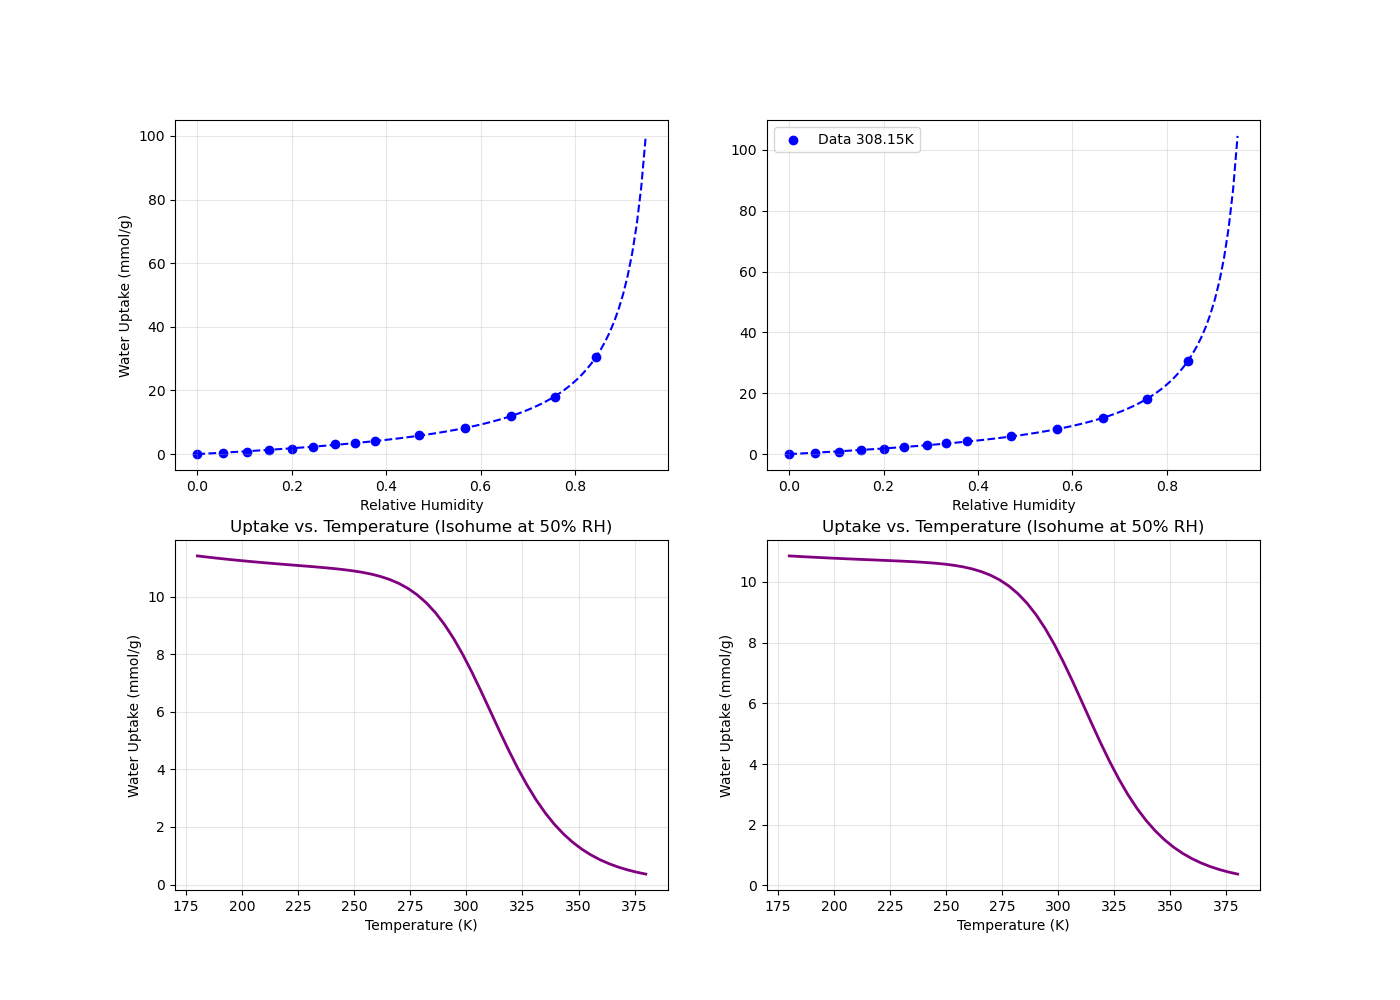

In [104]:
# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()
colors = {308.15: 'blue'}
RH_plot = np.linspace(0, 0.95, 100)

for T_val in T_values:
    subset = gab_h2o[gab_h2o['Temp (K)'] == T_val]
    RH_sub = subset['RH'].values
    
    # Plot Data on both
    axs[0].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val}K')
    axs[1].scatter(RH_sub, subset['Adsorption (mmol/g)'], color=colors[T_val], label=f'Data {T_val}K')
    
    T_plot = np.full_like(RH_plot, T_val)
    
    # First curve
    q_pred_A = GAB_model_fit_dH(best_params_roam, RH_plot, T_plot)
    axs[0].plot(RH_plot, q_pred_A, '--', color=colors[T_val])
    
    # Second curve
    q_pred_B = GAB_model_fit_dH_C(best_params_fix, RH_plot, T_plot)
    axs[1].plot(RH_plot, q_pred_B, '--', color=colors[T_val])

axs[0].set_xlabel('Relative Humidity')
axs[0].set_ylabel('Water Uptake (mmol/g)')
axs[0].grid(True, alpha=0.3)

axs[1].set_xlabel('Relative Humidity')
axs[1].grid(True, alpha=0.3)
axs[1].legend()

# Plot 2: Uptake vs Temperature at 50% RH
T_range = np.linspace(180, 380, 50)
RH_constant = np.full_like(T_range, 0.50)
q_temp_decay = GAB_model_fit_dH(best_params_roam, RH_constant, T_range)

axs[2].plot(T_range, q_temp_decay, color='purple', linewidth=2)
axs[2].set_xlabel('Temperature (K)')
axs[2].set_ylabel('Water Uptake (mmol/g)')
axs[2].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[2].grid(True, alpha=0.3)

q_temp_decay1 = GAB_model_fit_dH_C(best_params_fix, RH_constant, T_range)

axs[3].plot(T_range, q_temp_decay1, color='purple', linewidth=2)
axs[3].set_xlabel('Temperature (K)')
axs[3].set_ylabel('Water Uptake (mmol/g)')
axs[3].set_title('Uptake vs. Temperature (Isohume at 50% RH)')
axs[3].grid(True, alpha=0.3)

plt.show()

In [100]:
# Try fitting with both ∆H_C and ∆H_K fixed
dH_C = -50890
dH_K_tests = [1000, 0, -1000]
num_starts = 500

# Bounds: [qm, C0, kG0]
init_lower = [0.1,  1e-12, 0.1]
init_upper = [10.0, 1.0,   1.0]

solver_lower = [0.001, 1e-16, 0.05]
solver_upper = [50.0,  1.0,  1.0]

for dH_K_test in dH_K_tests:
    dH_K = dH_K_test
    
    best_res = np.inf
    best_params = None
    
    for i in range(num_starts):
        x0 = np.random.uniform(low=init_lower, high=init_upper)
        try:
            res = least_squares(
                residuals_GAB, x0, 
                args=(RH_array, Temps_h2o, y_h2o),
                bounds=(solver_lower, solver_upper), method='trf'
            )
            if res.success and sum(res.fun**2) < best_res:
                best_res = sum(res.fun**2)
                best_params = res.x
        except: pass
        
    print(f"dH_K = {dH_K_test} J/mol")
    print(f"   SSR: {best_res:.4f}")
    print(f"   qm : {best_params[0]:.4f} mmol/g")
    print(f"   C0 : {best_params[1]:.4e}")
    print(f"   kG0: {best_params[2]:.4f}")
    
    for T in T_values:
        C = best_params[1] * np.exp(-dH_C/ (R * T))
        K = best_params[2] * np.exp(-dH_K_test / (R * T))
        print(f"      T={T}K -> C = {C:.2f} | K = {K:.4f}")
    print("-" * 50)

dH_K = 1000 J/mol
   SSR: 114.5855
   qm : 14.1573 mmol/g
   C0 : 3.0724e-09
   kG0: 1.0000
      T=308.15K -> C = 1.30 | K = 0.6768
--------------------------------------------------
dH_K = 0 J/mol
   SSR: 0.2264
   qm : 5.3045 mmol/g
   C0 : 3.6875e-09
   kG0: 1.0000
      T=308.15K -> C = 1.56 | K = 1.0000
--------------------------------------------------
dH_K = -1000 J/mol
   SSR: 0.2317
   qm : 5.3536 mmol/g
   C0 : 3.6086e-09
   kG0: 0.6762
      T=308.15K -> C = 1.53 | K = 0.9990
--------------------------------------------------


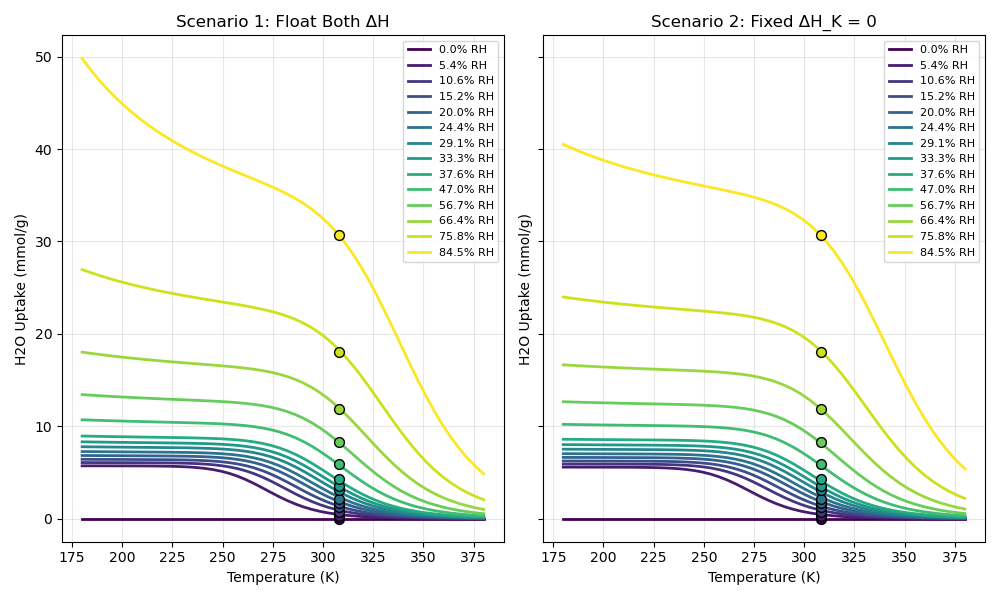

In [105]:
# Compare fits against raw data
gab_h2o['RH_rounded'] = gab_h2o['RH'].round(4)

unique_rhs = sorted(gab_h2o['RH_rounded'].unique())

fig, axs = plt.subplots(1, 2, figsize=(10,6), sharey=True)
axs = axs.flatten()

params1 = best_params_roam
params2 = best_params_fix

scenarios = [
    ("Scenario 1: Float Both \u0394H", GAB_model_fit_dH, params1),
    ("Scenario 2: Fixed \u0394H_K = 0", GAB_model_fit_dH_C, params2),
]

color_map = cm.get_cmap('viridis', len(unique_rhs))

for col, (title, func, params) in enumerate(scenarios):
    ax = axs[col]
    
    for idx, rh_val in enumerate(unique_rhs):
        c = color_map(idx)
        
        # Plot Model Isohume
        rh_array = np.full_like(T_range, rh_val)
        q_sim = func(params, rh_array, T_range)
        ax.plot(T_range, q_sim, color=c, linewidth=2, label=f'{rh_val*100:.1f}% RH')
        
        # Plot matching raw data
        subset = gab_h2o[gab_h2o['RH_rounded'] == rh_val]
        ax.scatter(subset['Temp (K)'], subset['Adsorption (mmol/g)'], 
                   color=c, s=50, edgecolor='black', zorder=5)

    ax.set_title(title)
    ax.set_xlabel('Temperature (K)')
    ax.set_ylabel('H2O Uptake (mmol/g)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

### WADST Fitting

In [111]:
def WADST_fit(x, P_co2, q_h2o, T):
    # Evaluate dry parameters
    qs_d = qs0_d * np.exp(chi_d * (1.0 - T / T0))
    b_d  = b0_d * np.exp((-dH_d / (R * T0)) * ((T0 / T) - 1.0))
    t_d  = t0_d + alpha_d * (1.0 - (T0 / T))

    # Evaluate wet parameters
    # x = [qs0_w, chi_w, b0_w, t0_w, alpha_w, A]
    qs_w = x[0] * np.exp(x[1] * (1.0 - T / T0))
    b_w  = x[2] * np.exp((-dH_w / (R * T0)) * ((T0 / T) - 1.0))
    t_w  = x[3] + x[4] * (1.0 - (T0 / T))

    # Dont model water below 1e-9
    q_safe = np.maximum(q_h2o, 1e-9)
    weight = np.exp(-x[5] / q_safe)

    # Calculate terms
    dry_term = (qs_d * b_d * P_co2) / ((1.0 + (b_d * P_co2)**t_d)**(1.0/t_d))
    wet_term = (qs_w * b_w * P_co2) / ((1.0 + (b_w * P_co2)**t_w)**(1.0/t_w))

    q_total = (1.0 - weight) * dry_term + weight * wet_term
    return q_total

def residuals_WADST(x, P_co2, q_h2o, T, q_exp):
    q_model = WADST_fit(x, P_co2, q_h2o, T)
    return q_model - q_exp

def gab_isotherm(RH, T):
    C = C0 * np.exp(-dH_C / (R * T))
    K = kG0 * np.exp(-dH_K / (R * T))
    
    num = qm_gab * C * K * RH
    den = (1 - K * RH) * (1 - K * RH + C * K * RH)
    return num / den    

In [110]:
# Jung and Lee WADST 
JL_WADST = pd.read_csv('JL_co2h2o_pts.csv')

P_h2o_JL = JL_WADST['pH2O (bar)'].values * 100  # kPa
P_co2_JL = JL_WADST['pCO2 (bar)'].values * 100  # kPa
T_JL = JL_WADST['Temp (K)'].values
y_co2_JL = JL_WADST['CO2 Adsorption (mmol/g)'].values

# Dry Toth Parameters
qs0_d = 3.3284
chi_d = -3.0860
b0_d = 76.0440
dH_d = -53970 
t0_d = 0.3436
alpha_d = -1.2472

# Wet CO2 Enthalpy
dH_w = -67670

# Water GAB Parameters
qm_gab = 3.4625
C0 = 6.4609e-09
kG0 = 0.05
dH_C = -57210
dH_K = -1437

RH_JL = get_RH(T_JL, P_h2o_JL)
q_h2o_JL = gab_isotherm(RH_JL, T_JL)

In [24]:
num_starts = 500
best_res = np.inf
best_params = None

# Variables: [qs0_w, chi_w, b0_w, t0_w, alpha_w, A]
init_lower = [0.1,  -10.0, 0,  0.001, -10.0, 0.01]
init_upper = [15.0,  10.0, 500.0, 1.0,    10.0, 5.0]

# Bounds for the solver 
solver_lower = [0.001, -100.0, 0,    1e-5, -100.0, 0.01]
solver_upper = [100.0,  100.0, 10000.0, 10.0,  100.0, 20.0]

for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    try:
        results = least_squares(
            residuals_WADST, 
            x0_random, 
            args=(P_co2_JL, q_h2o_JL, T_JL, y_co2_JL),
            bounds=(solver_lower, solver_upper),
            method='trf'
        )
        if results.success and sum(results.fun**2) < best_res:
            best_res = sum(results.fun**2)
            best_params = results.x
    except:
        pass

# Print Output
print(f"Global Best SSR: {best_res:.4f}")
print(f"qs0_w  : {best_params[0]:.4f} mmol/g")
print(f"chi_w  : {best_params[1]:.4f}")
print(f"b0_w   : {best_params[2]:.4f} kPa^-1")
print(f"t0_w   : {best_params[3]:.4f}")
print(f"alpha_w: {best_params[4]:.4f}")
print(f"A (wt) : {best_params[5]:.4f} mmol/g")

Global Best SSR: 0.5264
qs0_w  : 3.7934 mmol/g
chi_w  : -2.0987
b0_w   : 0.6683 kPa^-1
t0_w   : 0.5812
alpha_w: 1.4668
A (wt) : 0.0100 mmol/g


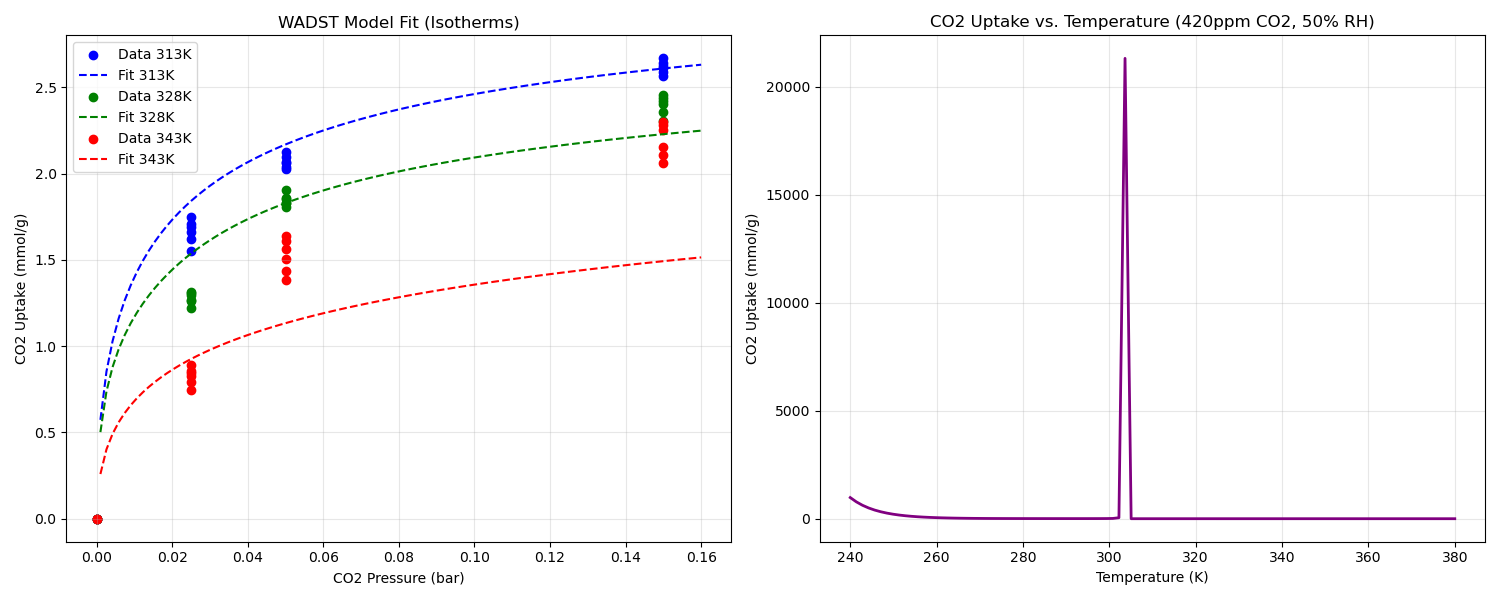

In [43]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0.001, 0.16, 100)
p_kPa = p_bar * 100

# Plot 1: Isotherm
unique_temps = np.unique(T_JL)
for T_val in unique_temps:
    subset = JL_WADST[JL_WADST['Temp (K)'] == T_val]
    if len(subset) == 0: continue
        
    c_key = int(T_val)
    lbl_color = colors.get(c_key, 'black')
    
    # Scatter Data
    axs[0].scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=lbl_color, label=f'Data {T_val}K')
    
    # Average the experimental water pressure for the modeled curve
    P_h2o_subset = subset['pH2O (bar)'].values * 100
    RH_subset = get_RH(T_val, P_h2o_subset)
    q_h2o_avg = np.mean(gab_isotherm(RH_subset, T_val))
    
    # Predict Curve
    q_pred_curve = WADST_fit(best_params, p_kPa, q_h2o_avg, T_val)
    axs[0].plot(p_bar, q_pred_curve, color=lbl_color, linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('CO2 Pressure (bar)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('WADST Model Fit (Isotherms)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Uptake vs Temp
# Modeling DAC conditions: CO2 at 420 ppm (0.042 kPa) and ~50% Relative Humidity
T_range = np.linspace(240, 380, 100)
P_co2_dac = np.full_like(T_range, 0.042)  # Fixed at 0.042 kPa CO2
RH_dac = np.full_like(T_range, 0.50)      # Fixed at 50% RH

q_h2o_dac = gab_isotherm(RH_dac, T_range)
q_dac_curve = WADST_fit(best_params, P_co2_dac, q_h2o_dac, T_range)

axs[1].plot(T_range, q_dac_curve, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('CO2 Uptake vs. Temperature (420ppm CO2, 50% RH)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Success: True
Residual: 0.4934827816494252
qs0 (Sat Capacity) : 3.7059 mmol/g
chi (Temp dep qs)  : -1.8427
b0 (Affinity)      : 1.8369 kPa-1
t0 (Heterogeneity) : 0.4911
alpha (Temp dep t) : 1.3259


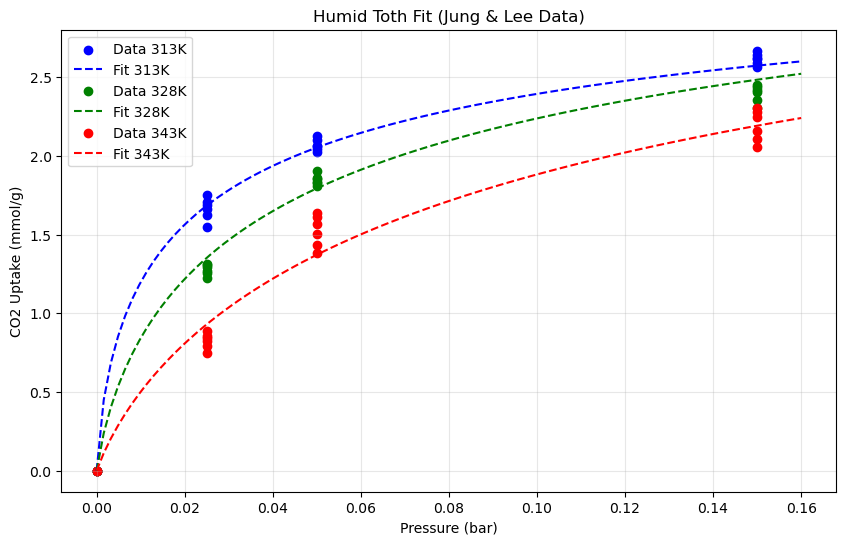

In [26]:
# Try fitting a Toth on humid data
JL_humid_Toth = pd.read_csv('JL_co2h2o_pts.csv')

T0 = 313 #K
dH = -67670 # Joules (∆H)

pressures_w = JL_humid_Toth['pCO2 (bar)'].values * 100 # to put in kPa
Temps_w = JL_humid_Toth['Temp (K)'].values
y_values_w = JL_humid_Toth['CO2 Adsorption (mmol/g)'].values

x0 = [2.72, 0.01, 36.11, 0.25, 0.2]

results = least_squares(residuals_toth, x0, args=(pressures_w, Temps_w, y_values_w),
            bounds=([-np.inf, -np.inf, -np.inf, -np.inf, -np.inf,], [np.inf, np.inf, np.inf, np.inf, np.inf]))

print("Success:", results.success)
print("Residual:", sum(results.fun**2))

params_fitted = results.x
print(f"qs0 (Sat Capacity) : {params_fitted[0]:.4f} mmol/g")
print(f"chi (Temp dep qs)  : {params_fitted[1]:.4f}")
print(f"b0 (Affinity)      : {params_fitted[2]:.4f} kPa-1")
print(f"t0 (Heterogeneity) : {params_fitted[3]:.4f}")
print(f"alpha (Temp dep t) : {params_fitted[4]:.4f}")

plt.figure(figsize=(10, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0, 0.16, 100)
p_kPa = p_bar * 100

for T_val in [313, 328, 343]:
    # Raw data points
    subset = JL_humid_Toth[JL_humid_Toth['Temp (K)'] == T_val]
    plt.scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], label=f'Data {T_val}K')
    
    # Fitted curve
    q_pred_curve = toth_model(params_fitted, p_kPa, T_val)
    plt.plot(p_bar, q_pred_curve, color=colors[T_val], linestyle='--', label=f'Fit {T_val}K')

plt.xlabel('Pressure (bar)')
plt.ylabel('CO2 Uptake (mmol/g)')
plt.title('Humid Toth Fit (Jung & Lee Data)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# Fit separate Toth models
T0 = 313
dH = -53970

# Dry Data
JLdry_co2_pts = pd.read_csv('JLdry_co2pts.csv')
pressures = JLdry_co2_pts['pCO2 (bar)'].values * 100 # to put in kPa
Temps = JLdry_co2_pts['Temp (K)'].values
y_values = JLdry_co2_pts['CO2 Adsorption (mmol/g)'].values

# Fitting
# x = [qs0, chi, b0, t0, alpha]
lower_b = [0.1, -10.0, 1e-5, 0.01, -10.0]
upper_b = [20.0, 10.0, 5000.0, 1.0, 10.0]
num_starts = 100

# Fit Dry Data
best_res_dry = np.inf
best_x_dry = None
for i in range(num_starts):
    x0 = np.random.uniform(low=lower_b, high=upper_b)
    try:
        res = least_squares(residuals_toth, x0, bounds=(lower_b, upper_b), 
                            args=(pressures, Temps, y_values), method='trf')
        if res.success and sum(res.fun**2) < best_res_dry:
            best_res_dry = sum(res.fun**2)
            best_x_dry = res.x
    except: pass

In [28]:
dH = -67670

# Humid Data
JL_humid_Toth = pd.read_csv('JL_co2h2o_pts.csv')
pressures_w = JL_humid_Toth['pCO2 (bar)'].values * 100 # to put in kPa
Temps_w = JL_humid_Toth['Temp (K)'].values
y_values_w = JL_humid_Toth['CO2 Adsorption (mmol/g)'].values

# Fitting
# x = [qs0, chi, b0, t0, alpha]
lower_b = [0.1, -10.0, 1e-5, 0.01, -10.0]
upper_b = [20.0, 10.0, 5000.0, 1.0, 10.0]
num_starts = 100

# Fit Humid Data
best_res_hum = np.inf
best_x_hum = None
for i in range(num_starts):
    x0 = np.random.uniform(low=lower_b, high=upper_b)
    try:
        res = least_squares(residuals_toth, x0, bounds=(lower_b, upper_b), 
                    args=(pressures_w, Temps_w, y_values_w), method='trf')
        if res.success and sum(res.fun**2) < best_res_hum:
            best_res_hum = sum(res.fun**2)
            best_x_hum = res.x
    except: pass


# Results
results_df = pd.DataFrame({
    "Parameter": ["qs0", "chi", "b0", "t0", "alpha", "SSR"],
    "Dry Fit": [best_x_dry[0], best_x_dry[1], best_x_dry[2], best_x_dry[3], best_x_dry[4], best_res_dry],
    "Humid Fit": [best_x_hum[0], best_x_hum[1], best_x_hum[2], best_x_hum[3], best_x_hum[4], best_res_hum]
}).round(4)

try:
    display(results_df)
except:
    print(results_df.to_string(index=False))

,Parameter,Dry Fit,Humid Fit
0,qs0,3.3284,3.7059
1,chi,-3.0860,-1.8423
2,b0,76.0450,1.8369
3,t0,0.3436,0.4911
4,alpha,-1.2471,1.3261
5,SSR,0.1524,0.4935


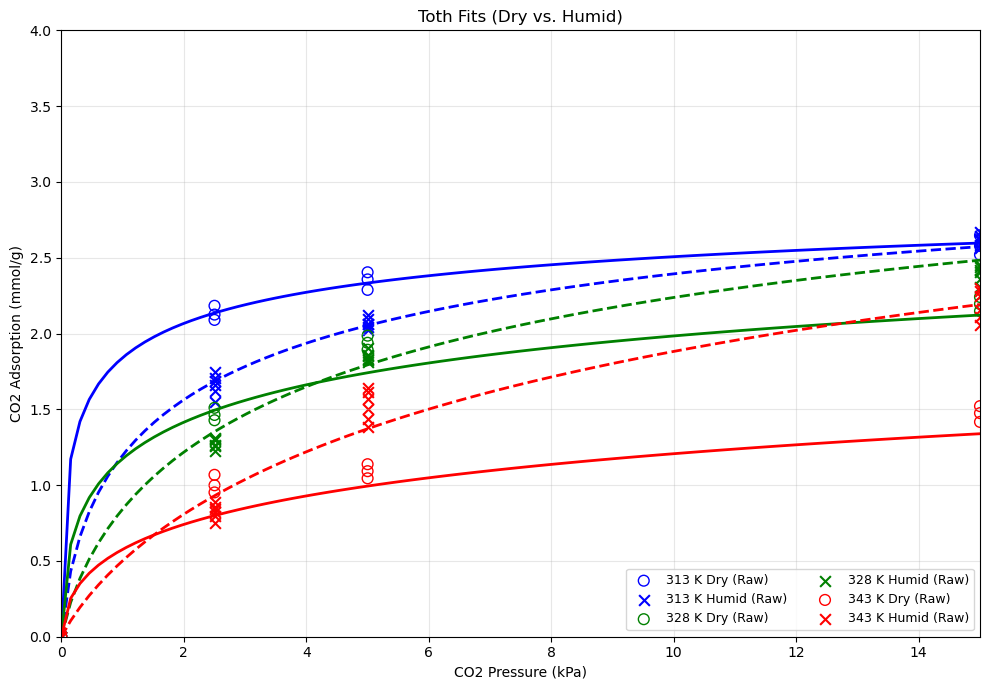

In [29]:
# Plot the overlay
fig, ax = plt.subplots(figsize=(10, 7))
T_vals = [313, 328, 343]
colors = {313: 'blue', 328: 'green', 343: 'red'}
P_smooth = np.linspace(0, 15, 100)

for T in T_vals:
    # Dry Raw Data & Model
    idx_d = Temps == T
    ax.scatter(pressures[idx_d], y_values[idx_d], color=colors[T], marker='o', facecolors='none', s=60, label=f'{T} K Dry (Raw)')
    
    T_array = np.full_like(P_smooth, T)
    ax.plot(P_smooth, toth_model(best_x_dry, P_smooth, T_array), color=colors[T], linestyle='-', linewidth=2)
    
    # Humid Raw Data & Model
    idx_h = T_JL == T
    ax.scatter(P_co2_JL[idx_h], y_co2_JL[idx_h], color=colors[T], marker='x', s=60, label=f'{T} K Humid (Raw)')
    
    ax.plot(P_smooth, toth_model(best_x_hum, P_smooth, T_array), color=colors[T], linestyle='--', linewidth=2)

ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
ax.set_title('Toth Fits (Dry vs. Humid)')
ax.set_xlabel('CO2 Pressure (kPa)')
ax.set_ylabel('CO2 Adsorption (mmol/g)')
ax.legend(loc='lower right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Try fitting WADST without 343K data
# Jung and Lee WADST 
JL_WADST = pd.read_csv('JL_co2h2o_no343.csv')

P_h2o_JL = JL_WADST['pH2O (bar)'].values * 100  # kPa
P_co2_JL = JL_WADST['pCO2 (bar)'].values * 100  # kPa
T_JL = JL_WADST['Temp (K)'].values
y_co2_JL = JL_WADST['CO2 Adsorption (mmol/g)'].values

# Dry Toth Parameters
qs0_d = 3.3284
chi_d = -3.0860
b0_d = 76.0440
dH_d = -53970 
t0_d = 0.3436
alpha_d = -1.2472

# Wet CO2 Enthalpy
dH_w = -67670

# Water GAB Parameters
qm_gab = 3.4131
C0 = 4.3156e-09
kG0 = 1.8574e-01
dH_C = -57210
dH_K = 0

RH_JL = get_RH(T_JL, P_h2o_JL)
q_h2o_JL = gab_isotherm(RH_JL, T_JL)

In [31]:
num_starts = 500
best_res = np.inf
best_params = None

# Variables: [qs0_w, chi_w, b0_w, t0_w, alpha_w, A]
init_lower = [0.1,  -10.0, 0,  0.001, -10.0, 0.01]
init_upper = [15.0,  10.0, 500.0, 1.0,    10.0, 5.0]

# Bounds for the solver 
solver_lower = [0.001, -100.0, 0,    1e-5, -100.0, 0.01]
solver_upper = [100.0,  100.0, 10000.0, 10.0,  100.0, 20.0]

for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    try:
        results = least_squares(
            residuals_WADST, 
            x0_random, 
            args=(P_co2_JL, q_h2o_JL, T_JL, y_co2_JL),
            bounds=(solver_lower, solver_upper),
            method='trf'
        )
        if results.success and sum(results.fun**2) < best_res:
            best_res = sum(results.fun**2)
            best_params = results.x
    except:
        pass

# Print Output
print(f"Global Best SSR: {best_res:.4f}")
print(f"qs0_w  : {best_params[0]:.4f} mmol/g")
print(f"chi_w  : {best_params[1]:.4f}")
print(f"b0_w   : {best_params[2]:.4f} kPa^-1")
print(f"t0_w   : {best_params[3]:.4f}")
print(f"alpha_w: {best_params[4]:.4f}")
print(f"A (wt) : {best_params[5]:.4f} mmol/g")

Global Best SSR: 0.0653
qs0_w  : 3.3565 mmol/g
chi_w  : 5.3857
b0_w   : 0.8428 kPa^-1
t0_w   : 0.6709
alpha_w: 18.8606
A (wt) : 0.0100 mmol/g


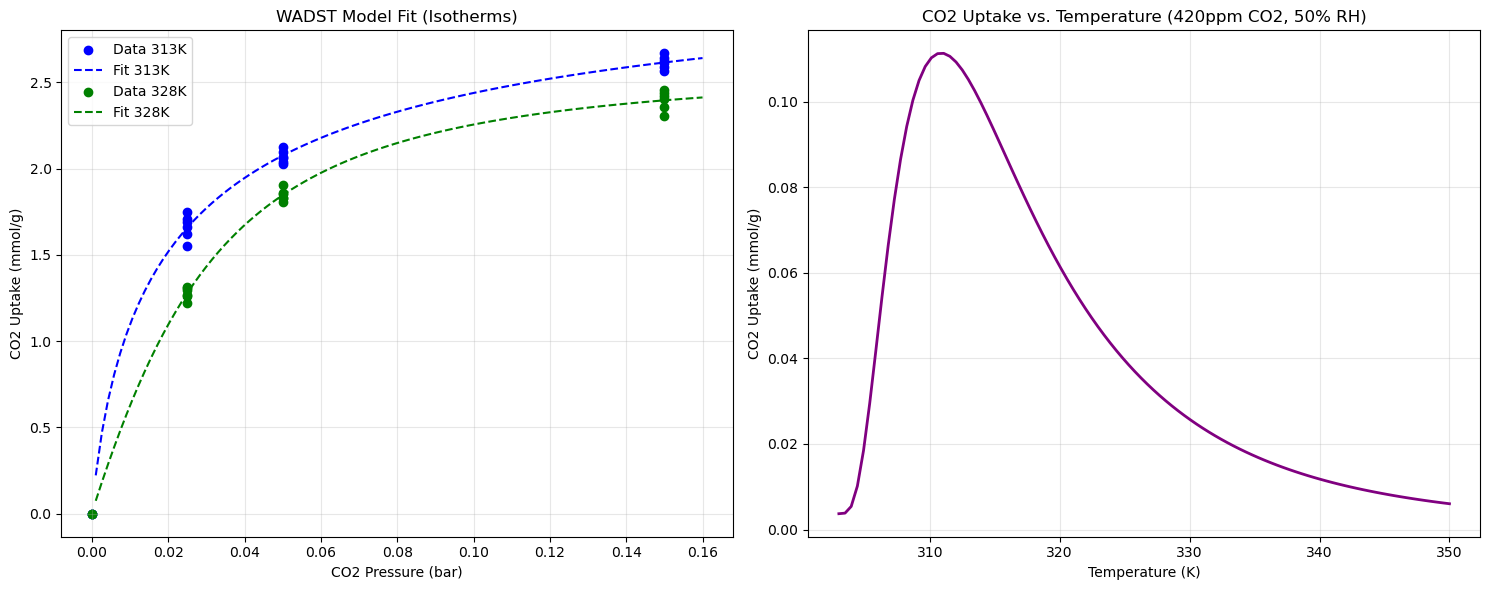

In [32]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0.001, 0.16, 100)
p_kPa = p_bar * 100

# Plot 1: Isotherm
unique_temps = np.unique(T_JL)
for T_val in unique_temps:
    subset = JL_WADST[JL_WADST['Temp (K)'] == T_val]
    if len(subset) == 0: continue
        
    c_key = int(T_val)
    lbl_color = colors.get(c_key, 'black')
    
    # Scatter Data
    axs[0].scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=lbl_color, label=f'Data {T_val}K')
    
    # Average the experimental water pressure for the modeled curve
    P_h2o_subset = subset['pH2O (bar)'].values * 100
    RH_subset = get_RH(T_val, P_h2o_subset)
    q_h2o_avg = np.mean(gab_isotherm(RH_subset, T_val))
    
    # Predict Curve
    q_pred_curve = WADST_fit(best_params, p_kPa, q_h2o_avg, T_val)
    axs[0].plot(p_bar, q_pred_curve, color=lbl_color, linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('CO2 Pressure (bar)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('WADST Model Fit (Isotherms)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Uptake vs Temp
# Modeling DAC conditions: CO2 at 420 ppm (0.042 kPa) and ~50% Relative Humidity
T_range = np.linspace(303, 350, 100)
P_co2_dac = np.full_like(T_range, 0.042)  # Fixed at 0.042 kPa CO2
RH_dac = np.full_like(T_range, 0.50)      # Fixed at 50% RH

q_h2o_dac = gab_isotherm(RH_dac, T_range)
q_dac_curve = WADST_fit(best_params, P_co2_dac, q_h2o_dac, T_range)

axs[1].plot(T_range, q_dac_curve, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('CO2 Uptake vs. Temperature (420ppm CO2, 50% RH)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Try simulating different water loadings
T0 = 313
dH_w = -67670

qs0_d, chi_d, b0_d, dH_d, t0_d, alpha_d = (3.3284, -3.0860, 76.0440, -53970, 0.3436, -1.2472)

# What happens if GAB predicts these flat amounts of water
artificial_water_levels = [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 5.0, 10.0]
num_starts = 100

# Bounds: [qs0_w, chi_w, b0_w, t0_w, alpha_w, A]
init_lower = [0.1,  -10.0, 1e-3,  0.001, -10.0, 0.01]
init_upper = [15.0,  10.0, 500.0, 1.0,    10.0, 5.0]
solver_lower = [0.001, -100.0, 1e-8,    1e-5, -100.0, 0.01]
solver_upper = [100.0,  100.0, 10000.0, 10.0,  100.0, 20.0]

results_list = []


for w_level in artificial_water_levels:
    fake_q_h2o = np.full_like(P_co2_JL, w_level)
    
    best_res = np.inf
    best_params = None
    
    for i in range(num_starts):
        x0 = np.random.uniform(low=init_lower, high=init_upper)
        try:
            res = least_squares(
                residuals_WADST, x0, 
                args=(P_co2_JL, fake_q_h2o, T_JL, y_co2_JL),
                bounds=(solver_lower, solver_upper), method='trf'
            )
            if res.success and sum(res.fun**2) < best_res:
                best_res = sum(res.fun**2)
                best_params = res.x
        except: pass
        
    results_list.append({
        "Tested H2O (mmol/g)": w_level,
        "SSR": round(best_res, 4),
        "qs0_w (Capacity)": round(best_params[0], 4),
        "chi_w" : round(best_params[1],4),
        "b0_w (Affinity)": round(best_params[2], 4),
        "t0_w" : round(best_params[3], 4),
        "alpha" : round(best_params[4], 4),
        "A (Weight)": round(best_params[5], 4)
    })

results_df = pd.DataFrame(results_list)
try:
    display(results_df) 
except:
    print(results_df.to_string(index=False))

,Tested H2O (mmol/g),SSR,qs0_w (Capacity),chi_w,b0_w (Affinity),t0_w,alpha,A (Weight)
0,0.10,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.0121
1,0.25,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.0303
2,0.50,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.0605
3,0.75,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.0908
4,1.00,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.1211
5,1.50,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.1816
6,2.00,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.2421
7,2.50,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.3026
8,3.00,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.3632
9,5.00,0.0648,3.5022,6.3425,0.7672,0.6459,23.1469,0.6053


In [119]:
# Liu WADST fitting
Liu_WADST = pd.read_csv('Liu_co2h2o_pts.csv')

P_co2_Liu = Liu_WADST['CO2 (kPa)'].values
T_Liu = Liu_WADST['Temp (K)'].values
y_co2_Liu = Liu_WADST['CO2 Adsorption (mmol/g)'].values

# Dry Toth parameters
qs0 = 1.1493
chi = -4.1214
b0 = 55020.8816
dH = -84000 
t0 = 0.1701
alpha = -0.2452
T0 = 298.15  # Reference temperature for Toth

# Wet CO2 Enthalpy
dH_w = -84000

# Water GAB parameters 
qm_gab = 5.3958
C0 = 4.4806e-09
kG0 = 0.9225
dH_C = -50287
dH_K = -201

RH_Liu = Liu_WADST['RH'].values / 100 # put into fraction
q_h2o_Liu = gab_isotherm(RH_Liu, T_Liu)

In [120]:
num_starts = 500
best_res = np.inf
best_params = None

# Variables: [qs0_w, chi_w, b0_w, t0_w, alpha_w, A]
init_lower = [0.1,  -10.0, 0,  0.001, -10.0, 0.01]
init_upper = [15.0,  10.0, 500.0, 1.0,    10.0, 5.0]

# Bounds for the solver 
solver_lower = [0.001, -100.0, 0,    1e-5, -100.0, 0.01]
solver_upper = [100.0,  100.0, 10000.0, 10.0,  100.0, 20.0]

for i in range(num_starts):
    x0_random = np.random.uniform(low=init_lower, high=init_upper)
    try:
        results = least_squares(
            residuals_WADST, 
            x0_random, 
            args=(P_co2_JL, q_h2o_JL, T_JL, y_co2_JL),
            bounds=(solver_lower, solver_upper),
            method='trf'
        )
        if results.success and sum(results.fun**2) < best_res:
            best_res = sum(results.fun**2)
            best_params = results.x
    except:
        pass

# Print Output
print(f"Global Best SSR: {best_res:.4f}")
print(f"qs0_w  : {best_params[0]:.4f} mmol/g")
print(f"chi_w  : {best_params[1]:.4f}")
print(f"b0_w   : {best_params[2]:.4f} kPa^-1")
print(f"t0_w   : {best_params[3]:.4f}")
print(f"alpha_w: {best_params[4]:.4f}")
print(f"A (wt) : {best_params[5]:.4f} mmol/g")

Global Best SSR: 0.6513
qs0_w  : 3.8016 mmol/g
chi_w  : -5.6206
b0_w   : 25.1685 kPa^-1
t0_w   : 0.3144
alpha_w: 0.2630
A (wt) : 0.0100 mmol/g


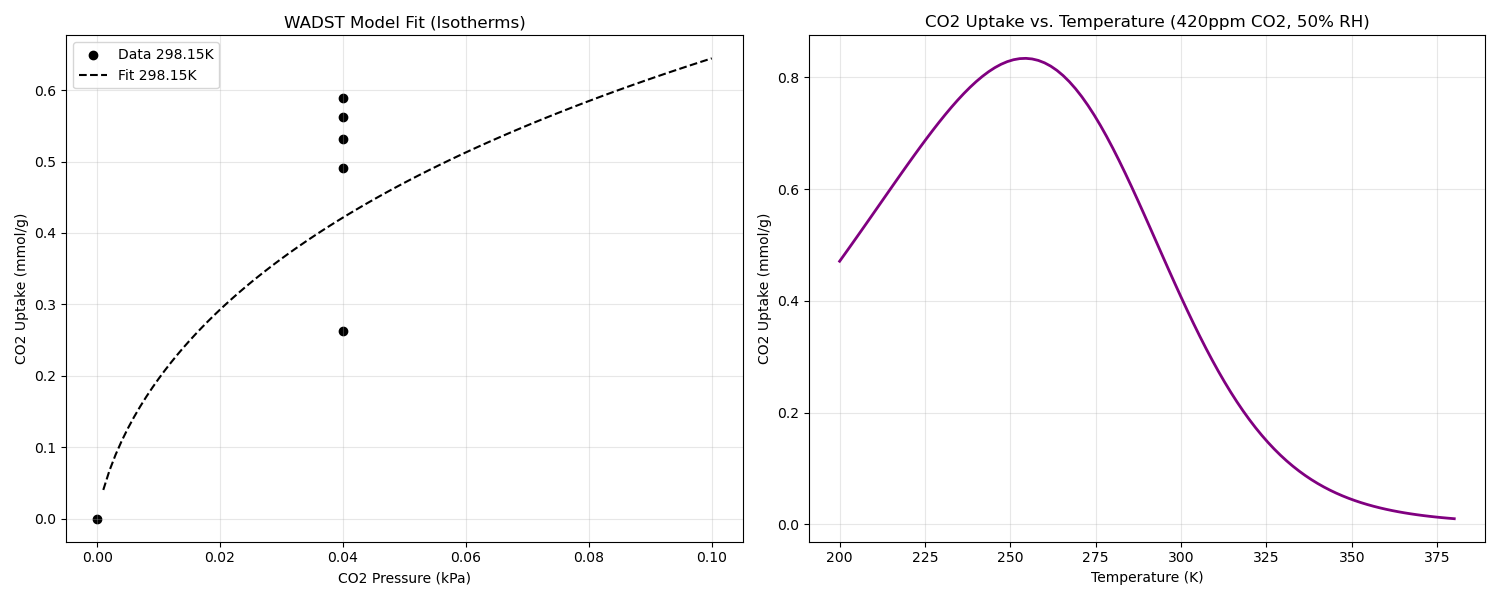

In [124]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colors = {298.15: 'blue'}

p_kPa = np.linspace(0.001, 0.1, 100)

# Plot 1: Isotherm
unique_temps = np.unique(T_Liu)
for T_val in unique_temps:
    subset = Liu_WADST[Liu_WADST['Temp (K)'] == T_val]
    if len(subset) == 0: continue
        
    c_key = int(T_val)
    lbl_color = colors.get(c_key, 'black')
    
    # Scatter Data
    axs[0].scatter(subset['CO2 (kPa)'], subset['CO2 Adsorption (mmol/g)'], 
                   color=lbl_color, label=f'Data {T_val}K')
    
    # Average the experimental water pressure for the modeled curve
    RH_subset = subset['RH'].values / 100
    q_h2o_avg = np.mean(gab_isotherm(RH_subset, T_val))
    
    # Predict Curve
    q_pred_curve = WADST_fit(best_params, p_kPa, q_h2o_avg, T_val)
    axs[0].plot(p_kPa, q_pred_curve, color=lbl_color, linestyle='--', label=f'Fit {T_val}K')

axs[0].set_xlabel('CO2 Pressure (kPa)')
axs[0].set_ylabel('CO2 Uptake (mmol/g)')
axs[0].set_title('WADST Model Fit (Isotherms)')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

# Plot 2: Uptake vs Temp
# Modeling DAC conditions: CO2 at 420 ppm (0.042 kPa) and ~50% Relative Humidity
T_range = np.linspace(200, 380, 100)
P_co2_dac = np.full_like(T_range, 0.042)  # Fixed at 0.042 kPa CO2
RH_dac = np.full_like(T_range, 0.50)      # Fixed at 50% RH

q_h2o_dac = gab_isotherm(RH_dac, T_range)
q_dac_curve = WADST_fit(best_params, P_co2_dac, q_h2o_dac, T_range)

axs[1].plot(T_range, q_dac_curve, color='purple', linewidth=2)
axs[1].set_xlabel('Temperature (K)')
axs[1].set_ylabel('CO2 Uptake (mmol/g)')
axs[1].set_title('CO2 Uptake vs. Temperature (420ppm CO2, 50% RH)')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### CATSO Fitting

In [145]:
def toth_water(b_h2o, RH, T):
    t_val  = t0 + alpha * (1.0 - (T0 / T))
    numerator = b_h2o * RH
    denominator = (1.0 + (b_h2o * RH)**t_val) ** (1.0 / t_val)
    return numerator / denominator

def residuals_water(b_h2o, RH, T, q_cov):
    return toth_water(b_h2o, RH, T) - q_cov

def theta_h2o(K, RH):
    x_h2o_m = 1.0 / K
    
    S = 20.0  # Hardcoded parameter from paper
    w = 1.0 / (1.0 + np.exp(-S * (RH - x_h2o_m)))
    
    theta_m = (1.0 - w) * K * RH + w
    
    return theta_m

def residuals_K(K, RH, q_cov):
    return theta_h2o(K, RH) - q_cov

def catso_total_model(params, P_co2, RH, T, theta_m):
    qs_wet0  = params[0]
    b_wet0   = params[1]
    t_wet0   = params[2]
    chi_wet  = params[3]
    alpha_wet = params[4]
    
    qs_dry = qs0 * np.exp(chi * (1.0 - (T / T0)))
    b_dry  = b0 * np.exp((-dH / (R * T0)) * ((T0 / T) - 1.0))
    t_dry  = t0 + alpha * (1.0 - (T0 / T))
    
    # Eq 15 Competitive Adsorption
    num_comp = qs_dry * b_dry * P_co2
    den_comp = (1.0 + (b_dry * P_co2)**t_dry + (fit_b_h2o * RH)**t_dry) ** (1.0 / t_dry)
    q_comp = num_comp / den_comp
    
    # Calculate wet parameters
    qs_wet = qs_wet0 * np.exp(chi_wet * (1.0 - (T / T0)))
    b_wet  = b_wet0 * np.exp((-dH_wet / (R * T0)) * ((T0 / T) - 1.0))
    t_wet  = t_wet0 + alpha_wet * (1.0 - (T0 / T))
    
    # Eq 16 Wet Sites Adsorption
    num_wet = qs_wet * b_wet * P_co2
    den_wet = (1.0 + (b_wet * P_co2)**t_wet) ** (1.0 / t_wet)
    q_wet = theta_m * (num_wet / den_wet)
    
    # Eq 14 Total CO2 Adsorption
    return q_comp + q_wet

def residuals_catso(params, P_co2, RH, T, theta_m, q_co2_exp):
    return catso_total_model(params, P_co2, RH, T, theta_m) - q_co2_exp

In [146]:
# Jung and Lee
# Fit water b_h2o
h2o_data = pd.read_csv('JL_h2o_pts.csv')

p_h2o = h2o_data['pH2O (bar)'].values * 100
T_h2o = h2o_data['Temp (K)'].values
y_h2o = h2o_data['Adsorption (mmol/g)'].values

RH = get_RH(T_h2o, p_h2o)

t0 = 0.3436
alpha = -1.2472
T0 = 313

q_m = 3.41 # PLACEHOLDER
q_cov = y_h2o / q_m

initial_guess = [75]
bounds = ([1e-5], [np.inf])

result = least_squares(
    residuals_water, 
    initial_guess, 
    bounds=bounds, 
    args=(RH, T_h2o, q_cov)
)

fit_b_h2o = result.x[0]
print(f"b_H2O: {fit_b_h2o:.6f}")

b_H2O: 42.794236


In [147]:
initial_guess = [2.0]  
bounds = ([1e-5], [np.inf])

result = least_squares(
    residuals_K, 
    initial_guess, 
    bounds=bounds, 
    args=(RH, q_cov)
)

fit_K = result.x[0]
predicted_x_m = 1.0 / fit_K

print(f"K: {fit_K:.6f}")
print(f"Monolayer Saturation RH (x_m): {predicted_x_m:.4f}")

K: 0.989140
Monolayer Saturation RH (x_m): 1.0110


In [148]:
JL_CATSO = pd.read_csv('JL_co2h2o_pts.csv')

T0 = 313 #K
dH = -53970 # Joules (∆H)

P_h2o_JL = JL_CATSO['pH2O (bar)'].values * 100 
P_co2_JL = JL_CATSO['pCO2 (bar)'].values * 100
T_JL = JL_CATSO['Temp (K)'].values
y_co2_JL = JL_CATSO['CO2 Adsorption (mmol/g)'].values

RH_JL = get_RH(T_JL, P_h2o_JL)
RH_h2o = get_RH(T_h2o, p_h2o)

# Dry CO2 Parameters
qs0 = 3.3284
chi = -3.0860
b0 = 76.0440
t0 = 0.3436
alpha = -1.2472

dH_wet = -67670

theta_m = theta_h2o(fit_K, RH_JL)

# Parameter fit
initial_guesses = [3.0, 70.0, 0.35, -3.0, -1.0]

# Bounds
lower_bounds = [0.1, 0.1, 0.01, -20.0, -20.0]
upper_bounds = [20.0, 5000.0, 1.0, 20.0, 20.0]

final_result = least_squares(
    residuals_catso,
    initial_guesses,
    bounds=(lower_bounds, upper_bounds),
    args=(P_co2_JL, RH_JL, T_JL, theta_m, y_co2_JL)
)


# Print results
w_p = final_result.x
print(f"qs_wet,0 : {w_p[0]:.4f} mmol/g")
print(f"b_wet,0 : {w_p[1]:.4f} 1/kPa")
print(f"t_wet,0 : {w_p[2]:.4f}")
print(f"chi_wet : {w_p[3]:.4f}")
print(f"alpha_wet : {w_p[4]:.4f}")

qs_wet,0 : 3.2913 mmol/g
b_wet,0 : 1.5447 1/kPa
t_wet,0 : 0.6658
chi_wet : -20.0000
alpha_wet : 8.7809


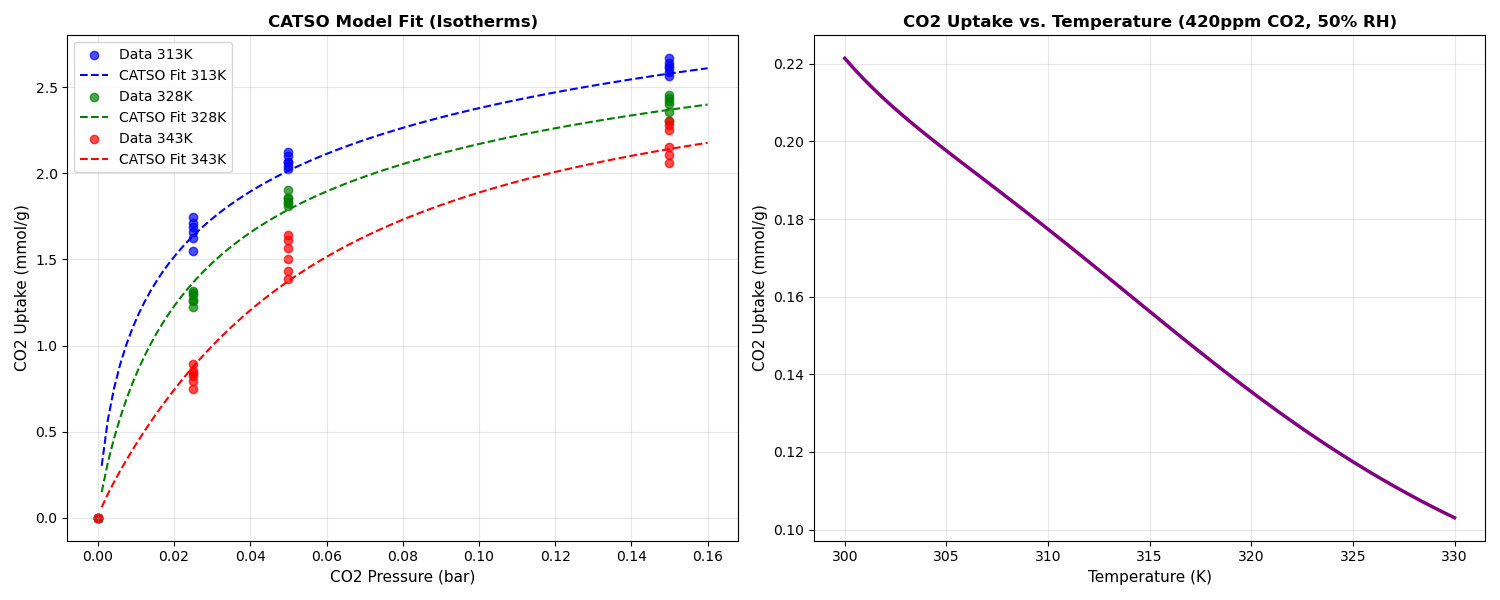

In [149]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colors = {313: 'blue', 328: 'green', 343: 'red'}

p_bar = np.linspace(0.001, 0.16, 100)
p_kPa = p_bar * 100

unique_temps = np.unique(JL_CATSO['Temp (K)'])

for T_val in unique_temps:
    subset = JL_CATSO[JL_CATSO['Temp (K)'] == T_val]
    if len(subset) == 0: 
        continue
        
    c_key = int(T_val)
    lbl_color = colors.get(c_key, 'black')
    
    # Scatter plot of raw data points
    axs[0].scatter(subset['pCO2 (bar)'], subset['CO2 Adsorption (mmol/g)'], 
                    color=lbl_color, label=f'Data {T_val}K', alpha=0.7)
    
    # Convert water pressures to fractional RH
    P_h2o_subset = subset['pH2O (bar)'].values * 100  # bar to kPa
    RH_subset = get_RH(T_val, P_h2o_subset)
    
    # Average the RH for this specific temperature
    RH_avg = np.mean(RH_subset)
    
    # Predict the smooth curve over pressure spectrum
    theta_curve = theta_h2o(fit_K, RH_avg)

    q_pred_curve = catso_total_model(
    final_result.x,
    p_kPa,
    RH_avg,
    T_val,
    theta_curve
    )
    axs[0].plot(p_bar, q_pred_curve, color=lbl_color, linestyle='--', label=f'CATSO Fit {T_val}K')

axs[0].set_xlabel('CO2 Pressure (bar)', fontsize=11)
axs[0].set_ylabel('CO2 Uptake (mmol/g)', fontsize=11)
axs[0].set_title('CATSO Model Fit (Isotherms)', fontsize=12, fontweight='bold')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

T_range = np.linspace(300, 330, 100)
P_co2_dac = np.full_like(T_range, 0.042)  # 420 ppm
RH_dac = np.full_like(T_range, 0.50)      # 50% RH

theta_dac = theta_h2o(fit_K, RH_dac)

q_dac_curve = catso_total_model(
    final_result.x,
    P_co2_dac,
    RH_dac,
    T_range,
    theta_dac
)

axs[1].plot(T_range, q_dac_curve, color='purple', linewidth=2.5, label='CATSO Profile')
axs[1].set_xlabel('Temperature (K)', fontsize=11)
axs[1].set_ylabel('CO2 Uptake (mmol/g)', fontsize=11)
axs[1].set_title('CO2 Uptake vs. Temperature (420ppm CO2, 50% RH)', fontsize=12, fontweight='bold')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [150]:
# Sensitivity analysis on qm water loading
# new function
def catso_total_model_b(params, P_co2, RH, T, theta_m, current_b_h2o):
    qs_wet0, b_wet0, t_wet0, chi_wet, alpha_wet = params
    
    qs_dry = qs0 * np.exp(chi * (1.0 - (T / T0)))
    b_dry  = b0 * np.exp((-dH / (R * T0)) * ((T0 / T) - 1.0))
    t_dry  = np.clip(t0 + alpha * (1.0 - (T0 / T)), 1e-5, 10)
    
    # Eq 15 Competitive Adsorption
    num_comp = qs_dry * b_dry * P_co2
    den_comp = (1.0 + (b_dry * P_co2)**t_dry + (current_b_h2o * RH)**t_dry) ** (1.0 / t_dry)
    q_comp = num_comp / den_comp
    
    # Calculate wet parameters
    qs_wet = qs_wet0 * np.exp(chi_wet * (1.0 - (T / T0)))
    b_wet  = np.clip(b_wet0 * np.exp((-dH_wet / (R * T0)) * ((T0 / T) - 1.0)), 1e-8, np.inf)
    t_wet  = np.clip(t_wet0 + alpha_wet * (1.0 - (T0 / T)), 1e-5, 10)
    
    # Eq 16 Wet Sites Adsorption
    num_wet = qs_wet * b_wet * P_co2
    den_wet = (1.0 + (b_wet * P_co2)**t_wet) ** (1.0 / t_wet)
    q_wet = theta_m * (num_wet / den_wet)
    
    return q_comp + q_wet

def residuals_catso(params, P_co2, RH, T, theta_m, current_b_h2o, q_co2_exp):
    return catso_total_model_b(params, P_co2, RH, T, theta_m, current_b_h2o) - q_co2_exp


qm_test_values = [1.0, 1.5, 1.96, 2.5, 3.0, 3.41, 4.0, 5.0]
num_starts = 50

results_list = []
fitted_models = {}

lower_bounds = [0.1, 0.1, 0.01, -20.0, -20.0]
upper_bounds = [20.0, 5000.0, 1.0, 20.0, 20.0]

In [151]:
for qm_val in qm_test_values:
    # 1. Fit b_h2o for this qm
    q_cov = y_h2o / qm_val
    res_b = least_squares(residuals_water, [75], bounds=([1e-5], [np.inf]), args=(RH_h2o, T_h2o, q_cov))
    fit_b_h2o = res_b.x[0]
    
    # 2. Fit K for this qm
    res_K = least_squares(residuals_K, [2.0], bounds=([1e-5], [np.inf]), args=(RH_h2o, q_cov))
    fit_K = res_K.x[0]
    
    # 3. Fit CATSO Wet Params
    theta_m_array = theta_h2o(fit_K, RH_JL)
    
    best_res = np.inf
    best_params = None
    
    for _ in range(num_starts):
        x0 = np.random.uniform(low=lower_bounds, high=upper_bounds)
        try:
            res = least_squares(
                residuals_catso, x0, 
                bounds=(lower_bounds, upper_bounds),
                args=(P_co2_JL, RH_JL, T_JL, theta_m_array, fit_b_h2o, y_co2_JL),
                method='trf'
            )
            if res.success and sum(res.fun**2) < best_res:
                best_res = sum(res.fun**2)
                best_params = res.x
        except: pass
        
    results_list.append({
        "q_m Assumed": qm_val,
        "fit_b_H2O": round(fit_b_h2o, 2),
        "fit_K": round(fit_K, 4),
        "SSR": round(best_res, 4),
        "qs_wet0": round(best_params[0], 4),
        "b_wet0": round(best_params[1], 4),
        "t_wet0": round(best_params[2], 4)
    })
    
    # Save params for plotting
    fitted_models[qm_val] = {
        'params': best_params,
        'b_h2o': fit_b_h2o,
        'K': fit_K
    }

# Print Table
results_df = pd.DataFrame(results_list)
try:
    display(results_df) 
except:
    print(results_df.to_string(index=False))

,q_m Assumed,fit_b_H2O,fit_K,SSR,qs_wet0,b_wet0,t_wet0
0,1.00,7234.13,2.8640,4.0468,3.4897,2.7605,0.4403
1,1.50,917.32,2.1130,3.7121,2.5822,1.6237,0.6848
2,1.96,293.15,1.6950,3.1289,2.6019,1.5439,0.7364
3,2.50,117.87,1.3452,2.3212,2.7935,1.5234,0.7597
4,3.00,63.82,1.1241,1.9091,3.0358,1.5252,0.7190
5,3.41,42.79,0.9891,1.6935,3.2913,1.5447,0.6658
6,4.00,26.86,0.8433,1.4920,3.7196,1.5824,0.5920
7,5.00,14.76,0.6746,1.3030,4.6333,1.6634,0.4888


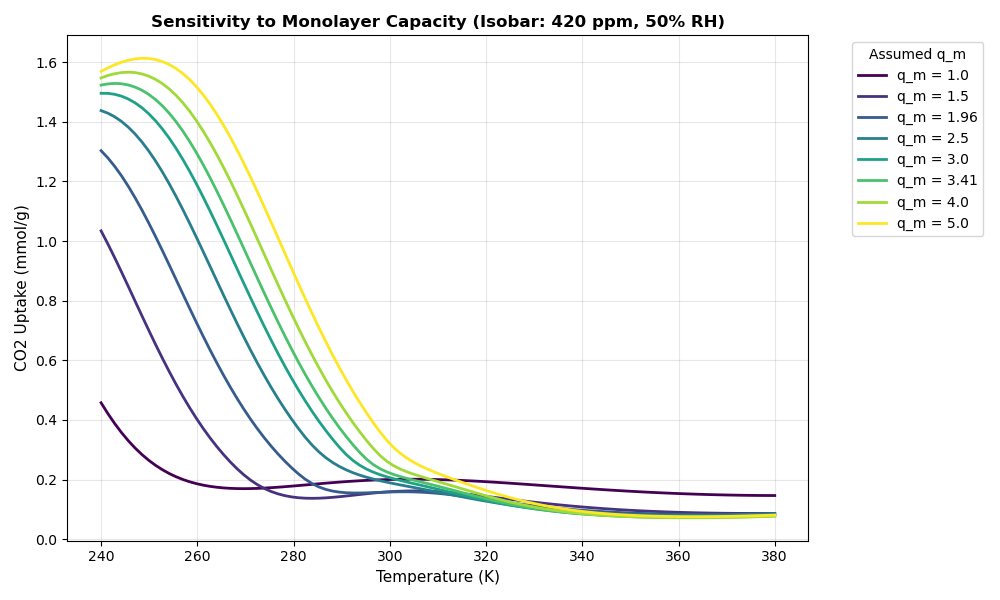

In [153]:
# Plotting Isobars
fig, ax = plt.subplots(figsize=(10, 6))

T_range = np.linspace(240, 380, 100)
P_co2_dac = np.full_like(T_range, 0.042)  # 420 ppm
RH_dac = np.full_like(T_range, 0.50)      # 50% RH

cmap = cm.get_cmap('viridis', len(qm_test_values))

for i, qm_val in enumerate(qm_test_values):
    mod = fitted_models[qm_val]
    
    # Calculate theta_m for DAC conditions
    theta_dac = theta_h2o(mod['K'], RH_dac)
    
    # Predict Curve
    q_dac_curve = catso_total_model_b(
        mod['params'], 
        P_co2_dac, 
        RH_dac, 
        T_range, 
        theta_dac, 
        mod['b_h2o']
    )
    
    ax.plot(T_range, q_dac_curve, color=cmap(i/len(qm_test_values)), 
            linewidth=2, label=f"q_m = {qm_val}")

ax.set_xlabel('Temperature (K)', fontsize=11)
ax.set_ylabel('CO2 Uptake (mmol/g)', fontsize=11)
ax.set_title('Sensitivity to Monolayer Capacity (Isobar: 420 ppm, 50% RH)', fontsize=12, fontweight='bold')
ax.legend(title="Assumed q_m", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [127]:
# Liu data
# Fit water b_h2o
h2o_data = pd.read_csv('Liu_h2o_pts.csv')

T_h2o = h2o_data['Temp (K)'].values
RH = h2o_data['RH'].values

t0 = 0.1701
alpha = -0.2452
T0 = 298.15

q_m = 5.39 # PLACEHOLDER
q_cov = y_h2o / q_m

initial_guess = [75]
bounds = ([1e-5], [np.inf])

result = least_squares(
    residuals_water, 
    initial_guess, 
    bounds=bounds, 
    args=(RH, T_h2o, q_cov)
)

fit_b_h2o = result.x[0]
print(f"b_H2O: {fit_b_h2o:.6f}")

b_H2O: 52426950.000000


In [128]:
initial_guess = [2.0]  
bounds = ([1e-5], [np.inf])

result = least_squares(
    residuals_K, 
    initial_guess, 
    bounds=bounds, 
    args=(RH, q_cov)
)

fit_K = result.x[0]
predicted_x_m = 1.0 / fit_K

print(f"K: {fit_K:.6f}")
print(f"Monolayer Saturation RH (x_m): {predicted_x_m:.4f}")

K: 1.907471
Monolayer Saturation RH (x_m): 0.5243


In [129]:
Liu_CATSO = pd.read_csv('Liu_co2h2o_pts.csv')

T0 = 298.15 #K
dH = -84000 # Joules (∆H)

P_co2_Liu = Liu_CATSO['CO2 (kPa)'].values
T_Liu = Liu_CATSO['Temp (K)'].values
y_co2_Liu = Liu_CATSO['CO2 Adsorption (mmol/g)'].values
RH_Liu = Liu_WADST['RH'].values / 100 # put into fraction

# Dry CO2 parameters
qs0 = 1.1493
chi = -4.1214
b0 = 55020.8816
dH = -84000 
t0 = 0.1701
alpha = -0.2452

dH_wet = -84000

theta_m = theta_h2o(fit_K, RH_JL)

# Parameter fit
initial_guesses = [3.0, 70.0, 0.35, -3.0, -1.0]

# Bounds
lower_bounds = [0.1, 0.1, 0.01, -20.0, -20.0]
upper_bounds = [20.0, 5000.0, 1.0, 20.0, 20.0]

final_result = least_squares(
    residuals_catso,
    initial_guesses,
    bounds=(lower_bounds, upper_bounds),
    args=(P_co2_JL, RH_JL, T_JL, theta_m, y_co2_JL)
)


# Print results
w_p = final_result.x
print(f"qs_wet,0 : {w_p[0]:.4f} mmol/g")
print(f"b_wet,0 : {w_p[1]:.4f} 1/kPa")
print(f"t_wet,0 : {w_p[2]:.4f}")
print(f"chi_wet : {w_p[3]:.4f}")
print(f"alpha_wet : {w_p[4]:.4f}")

qs_wet,0 : 2.1208 mmol/g
b_wet,0 : 16.0165 1/kPa
t_wet,0 : 0.3256
chi_wet : -17.4770
alpha_wet : 1.5558


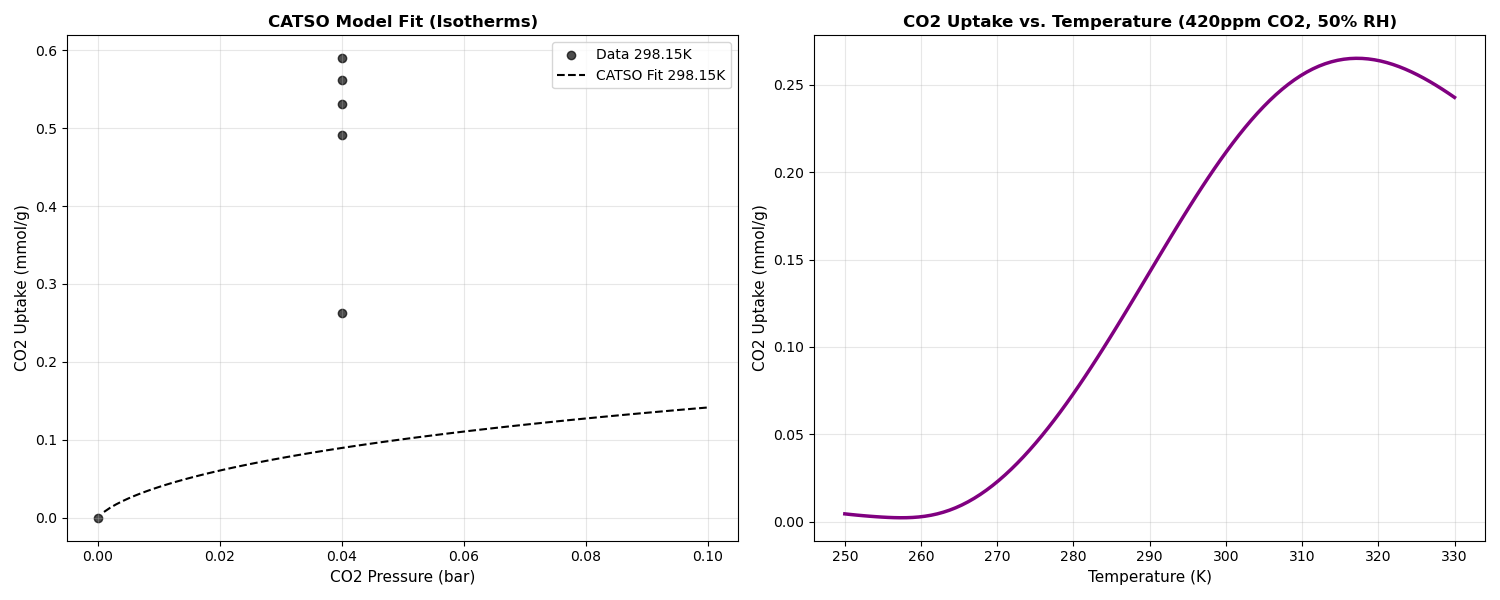

In [131]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
colors = {298.15: 'blue'}

p_kPa = np.linspace(0.001, 0.1, 100)

unique_temps = np.unique(Liu_CATSO['Temp (K)'])

for T_val in unique_temps:
    subset = Liu_CATSO[Liu_CATSO['Temp (K)'] == T_val]
    if len(subset) == 0: 
        continue
        
    c_key = int(T_val)
    lbl_color = colors.get(c_key, 'black')
    
    # Scatter plot of raw data points
    axs[0].scatter(subset['CO2 (kPa)'], subset['CO2 Adsorption (mmol/g)'], 
                    color=lbl_color, label=f'Data {T_val}K', alpha=0.7)
    
    # Convert water pressures to fractional RH
    RH_subset = subset['RH'].values / 100
    
    # Average the RH for this specific temperature
    RH_avg = np.mean(RH_subset)
    
    # Predict the smooth curve over pressure spectrum
    theta_curve = theta_h2o(fit_K, RH_avg)

    q_pred_curve = catso_total_model(
    final_result.x,
    p_kPa,
    RH_avg,
    T_val,
    theta_curve
    )
    axs[0].plot(p_kPa, q_pred_curve, color=lbl_color, linestyle='--', label=f'CATSO Fit {T_val}K')

axs[0].set_xlabel('CO2 Pressure (bar)', fontsize=11)
axs[0].set_ylabel('CO2 Uptake (mmol/g)', fontsize=11)
axs[0].set_title('CATSO Model Fit (Isotherms)', fontsize=12, fontweight='bold')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

T_range = np.linspace(250, 330, 100)
P_co2_dac = np.full_like(T_range, 0.042)  # 420 ppm
RH_dac = np.full_like(T_range, 0.50)      # 50% RH

theta_dac = theta_h2o(fit_K, RH_dac)

q_dac_curve = catso_total_model(
    final_result.x,
    P_co2_dac,
    RH_dac,
    T_range,
    theta_dac
)

axs[1].plot(T_range, q_dac_curve, color='purple', linewidth=2.5, label='CATSO Profile')
axs[1].set_xlabel('Temperature (K)', fontsize=11)
axs[1].set_ylabel('CO2 Uptake (mmol/g)', fontsize=11)
axs[1].set_title('CO2 Uptake vs. Temperature (420ppm CO2, 50% RH)', fontsize=12, fontweight='bold')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Toggle-able Interactive plots

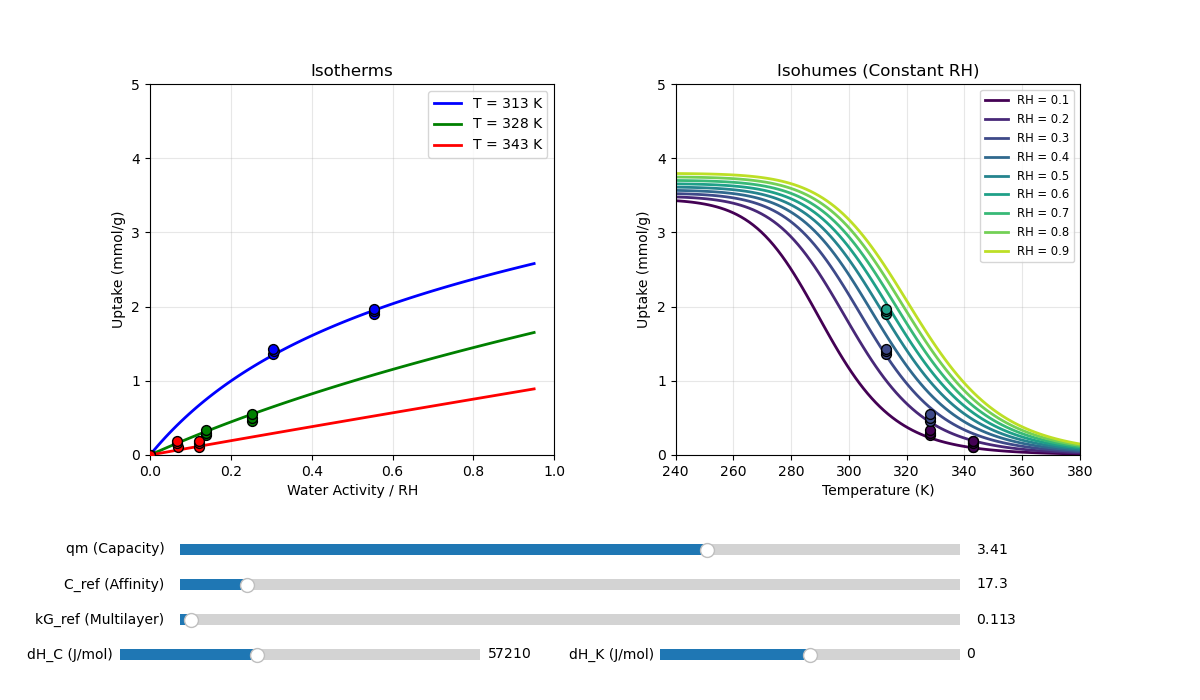

In [45]:
# GAB
%matplotlib widget
R = 8.314
T_ref = 313 
T_values = [313, 328, 343]
RH_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
gab_h2o = pd.read_csv('JL_h2o_pts.csv')
gab_h2o['RH'] = get_RH(gab_h2o['Temp (K)'].values, gab_h2o['pH2O (bar)'].values * 100)

def calc_gab(RH, T, qm, C_ref, kG_ref, dH_C, dH_K):
    C_val = C_ref * np.exp((dH_C / R) * (1.0/T - 1.0/T_ref))
    kG_val = kG_ref * np.exp((dH_K / R) * (1.0/T - 1.0/T_ref))
    
    num = qm * C_val * kG_val * RH
    den = (1.0 - kG_val * RH) * (1.0 + (C_val - 1.0) * kG_val * RH)
    return num / den

# Initial Parameter Values
init_qm = 3.41
init_C = 17.3
init_kG = 0.113
init_dHC = 57210
init_dHK = 0

RH_plot = np.linspace(0, 0.95, 100)
T_plot = np.linspace(240, 380, 100)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 7))
plt.subplots_adjust(bottom=0.35, wspace=0.3)

# Plot 1: Isotherms
colors = {T_values[0]: 'blue', T_values[1]: 'green', T_values[2]: 'red'}
iso_lines = {}
for T_val in T_values:
    q_pred = calc_gab(RH_plot, T_val, init_qm, init_C, init_kG, init_dHC, init_dHK)
    line, = ax1.plot(RH_plot, q_pred, color=colors[T_val], linewidth=2, label=f'T = {T_val} K')
    iso_lines[T_val] = line

    # raw data
    subset = gab_h2o[gab_h2o['Temp (K)'] == T_val]
    ax1.scatter(subset['RH'], subset['Adsorption (mmol/g)'], 
                color=colors[T_val], s=50, edgecolor='black', zorder=5)

ax1.set_xlim(0, 1.0)
ax1.set_ylim(0, 5)
ax1.set_title('Isotherms')
ax1.set_xlabel('Water Activity / RH')
ax1.set_ylabel('Uptake (mmol/g)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Isohumes
isohume_lines = {}
rh_colors = cm.viridis(np.linspace(0, 0.9, len(RH_values)))

for i, rh in enumerate(RH_values):
    q_iso_pred = calc_gab(rh, T_plot, init_qm, init_C, init_kG, init_dHC, init_dHK)
    line, = ax2.plot(T_plot, q_iso_pred, color=rh_colors[i], linewidth=2, label=f'RH = {rh}')
    isohume_lines[rh] = line

    # Raw data
    subset = gab_h2o[np.isclose(gab_h2o['RH'], rh, atol=0.05)]
    if not subset.empty:
        ax2.scatter(subset['Temp (K)'], subset['Adsorption (mmol/g)'], 
                    color=rh_colors[i], s=50, edgecolor='black', zorder=5)

ax2.set_xlim(240, 380)
ax2.set_ylim(0, 5)
ax2.set_title('Isohumes (Constant RH)')
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Uptake (mmol/g)')
ax2.legend(fontsize='small', loc='upper right')
ax2.grid(True, alpha=0.3)

# Sliders
axcolor = 'lightgoldenrodyellow'
ax_qm  = plt.axes([0.15, 0.20, 0.65, 0.03], facecolor=axcolor)
ax_C   = plt.axes([0.15, 0.15, 0.65, 0.03], facecolor=axcolor)
ax_kG  = plt.axes([0.15, 0.10, 0.65, 0.03], facecolor=axcolor)
ax_dHC = plt.axes([0.10, 0.05, 0.30, 0.03], facecolor=axcolor)
ax_dHK = plt.axes([0.55, 0.05, 0.25, 0.03], facecolor=axcolor)

s_qm  = Slider(ax_qm, 'qm (Capacity)', 0.1, 5.0, valinit=init_qm)
s_C   = Slider(ax_C, 'C_ref (Affinity)', 0.1, 200.0, valinit=init_C)
s_kG  = Slider(ax_kG, 'kG_ref (Multilayer)', 0.1, 0.99, valinit=init_kG)
s_dHC = Slider(ax_dHC, 'dH_C (J/mol)', 0, 150000, valinit=init_dHC)
s_dHK = Slider(ax_dHK, 'dH_K (J/mol)', -5000, 5000, valinit=init_dHK)


def update(val):
    qm = s_qm.val
    C = s_C.val
    kG = s_kG.val
    dHC = s_dHC.val
    dHK = s_dHK.val
    
    for T_val in T_values:
        new_q = calc_gab(RH_plot, T_val, qm, C, kG, dHC, dHK)
        iso_lines[T_val].set_ydata(new_q)
        
    for rh in RH_values:
        new_iso_q = calc_gab(rh, T_plot, qm, C, kG, dHC, dHK)
        isohume_lines[rh].set_ydata(new_iso_q)
    
    fig.canvas.draw_idle()

s_qm.on_changed(update)
s_C.on_changed(update)
s_kG.on_changed(update)
s_dHC.on_changed(update)
s_dHK.on_changed(update)

plt.show()


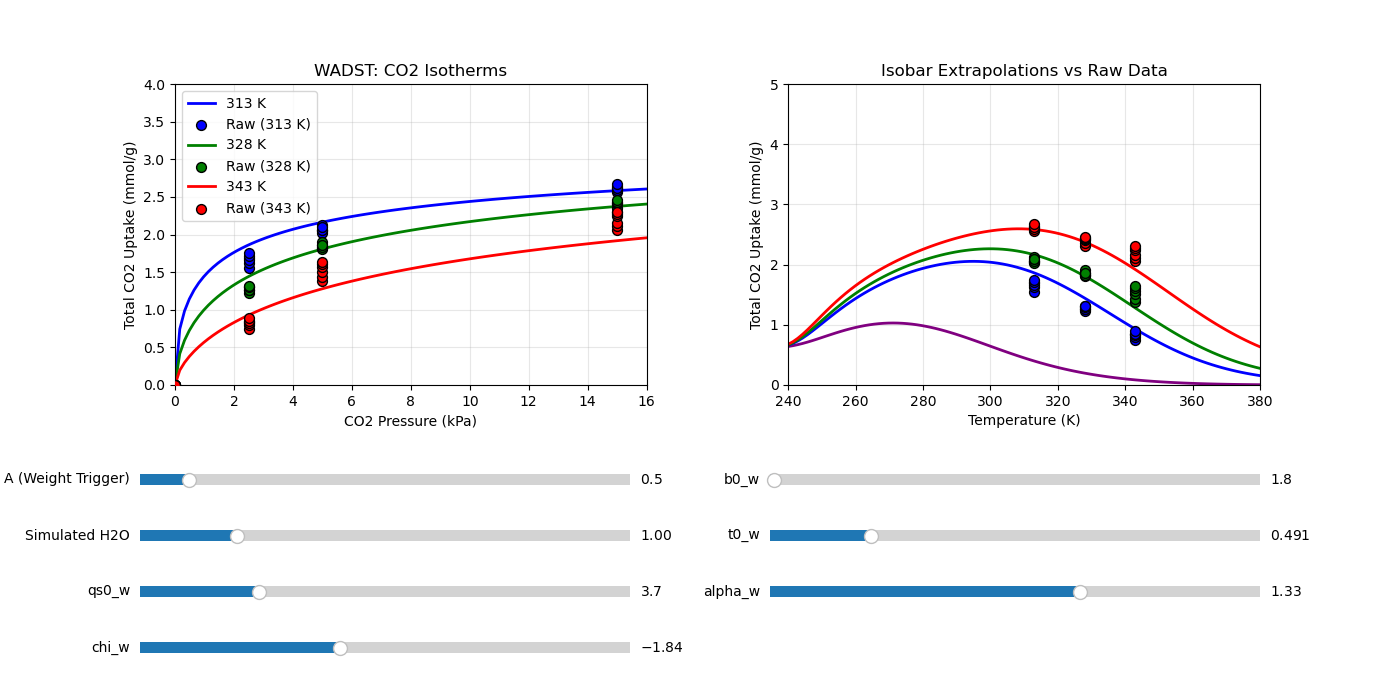

In [44]:
# WADST
JL_WADST = pd.read_csv('JL_co2h2o_pts.csv')
JL_WADST['P_kPa'] = JL_WADST['pCO2 (bar)'].values * 100

R = 8.314
T0 = 313
T_values = [313, 328, 343]

# Dry Toth Parameters
qs0_d = 3.3284
chi_d = -3.0860
b0_d = 76.0440
dH_d = -53970
t0_d = 0.3436
alpha_d = -1.2472

dH_w = -67670 # Fixed wet enthalpy

def calc_wadst(P_co2, T, q_h2o, qs0_w, chi_w, b0_w, t0_w, alpha_w, A_val):
    qs_d = qs0_d * np.exp(chi_d * (1.0 - T / T0))
    b_d  = b0_d * np.exp((-dH_d / (R * T0)) * ((T0 / T) - 1.0))
    t_d  = np.clip(t0_d + alpha_d * (1.0 - (T0 / T)), 1e-5, 10)
    
    qs_w = qs0_w * np.exp(chi_w * (1.0 - T / T0))
    b_w  = np.clip(b0_w * np.exp((-dH_w / (R * T0)) * ((T0 / T) - 1.0)), 1e-8, np.inf)
    t_w  = np.clip(t0_w + alpha_w * (1.0 - (T0 / T)), 1e-5, 10)
    
    q_h2o_safe = np.clip(q_h2o, 1e-5, np.inf)
    
    weight = np.exp(-A_val / q_h2o_safe)
    
    dry_term = (qs_d * b_d * P_co2) / ((1.0 + (b_d * P_co2)**t_d)**(1.0/t_d))
    wet_term = (qs_w * b_w * P_co2) / ((1.0 + (b_w * P_co2)**t_w)**(1.0/t_w))
    
    return (1.0 - weight) * dry_term + weight * wet_term

init_A = 0.5
init_qH2O = 1.0
init_qsw = 3.7059
init_bw = 1.8421
init_tw = 0.4911
init_chiw = -1.8421
init_alphaw = 1.3263

# Arrays for plotting
P_plot = np.linspace(0, 16, 100)
T_plot = np.linspace(240, 380, 100)

# Pressures for Plot 2 (in kPa)
isobar_pressures = [0.042, 2.5, 5.0, 15.0]
isobar_colors = ['purple', 'blue', 'green', 'red']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
plt.subplots_adjust(bottom=0.45, wspace=0.3)

colors = {T_values[0]: 'blue', T_values[1]: 'green', T_values[2]: 'red'}

# Plot 1: CO2 Isotherms
iso_lines = {}
for T_val in T_values:
    q_pred = calc_wadst(P_plot, T_val, init_qH2O, init_qsw, init_chiw, init_bw, init_tw, init_alphaw, init_A)
    line, = ax1.plot(P_plot, q_pred, color=colors[T_val], linewidth=2, label=f'{T_val} K')
    iso_lines[T_val] = line
    
    # Raw Data scatter
    subset = JL_WADST[JL_WADST['Temp (K)'] == T_val]
    ax1.scatter(subset['P_kPa'], subset['CO2 Adsorption (mmol/g)'], 
                color=colors[T_val], s=50, edgecolor='black', zorder=5, label=f'Raw ({T_val} K)')

ax1.set_xlim(0, 16)
ax1.set_ylim(0, 4)
ax1.set_title('WADST: CO2 Isotherms')
ax1.set_xlabel('CO2 Pressure (kPa)')
ax1.set_ylabel('Total CO2 Uptake (mmol/g)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Isobars
isobar_lines = {}
for i, P_val in enumerate(isobar_pressures):
    c = isobar_colors[i]
    
    # Model line
    q_iso = calc_wadst(P_val, T_plot, init_qH2O, init_qsw, init_chiw, init_bw, init_tw, init_alphaw, init_A)
    label = 'DAC (0.042 kPa)' if P_val == 0.042 else f'{P_val} kPa'
    line, = ax2.plot(T_plot, q_iso, color=c, linewidth=2, label=f'Model ({label})')
    isobar_lines[P_val] = line
    
    # Add raw data scatter
    if P_val != 0.042:
        subset = JL_WADST[np.isclose(JL_WADST['P_kPa'], P_val, atol=0.1)]
        ax2.scatter(subset['Temp (K)'], subset['CO2 Adsorption (mmol/g)'], 
                    color=c, s=50, edgecolor='black', zorder=5, label=f'Raw ({P_val} kPa)')

ax2.set_xlim(240, 380)
ax2.set_ylim(0, 5)
ax2.set_title('Isobar Extrapolations vs Raw Data')
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Total CO2 Uptake (mmol/g)')
ax2.grid(True, alpha=0.3)

# Sliders
axcolor = 'lightgoldenrodyellow'

# Column 1
ax_A      = plt.axes([0.10, 0.30, 0.35, 0.03], facecolor=axcolor)
ax_qH2O   = plt.axes([0.10, 0.22, 0.35, 0.03], facecolor=axcolor)
ax_qsw    = plt.axes([0.10, 0.14, 0.35, 0.03], facecolor=axcolor)
ax_chiw   = plt.axes([0.10, 0.06, 0.35, 0.03], facecolor=axcolor)

# Column 2
ax_bw     = plt.axes([0.55, 0.30, 0.35, 0.03], facecolor=axcolor)
ax_tw     = plt.axes([0.55, 0.22, 0.35, 0.03], facecolor=axcolor)
ax_alphaw = plt.axes([0.55, 0.14, 0.35, 0.03], facecolor=axcolor)

s_A       = Slider(ax_A, 'A (Weight Trigger)', 0.0, 5.0, valinit=init_A)
s_qH2O    = Slider(ax_qH2O, 'Simulated H2O', 0.01, 5.0, valinit=init_qH2O)
s_qsw     = Slider(ax_qsw, 'qs0_w', 0.1, 15.0, valinit=init_qsw)
s_chiw    = Slider(ax_chiw, 'chi_w', -10.0, 10.0, valinit=init_chiw)
s_bw      = Slider(ax_bw, 'b0_w', 0.1, 200.0, valinit=init_bw)
s_tw      = Slider(ax_tw, 't0_w', 0.1, 2.0, valinit=init_tw)
s_alphaw  = Slider(ax_alphaw, 'alpha_w', -5.0, 5.0, valinit=init_alphaw)


def update(val):
    A = s_A.val
    h2o = s_qH2O.val
    qsw = s_qsw.val
    chiw = s_chiw.val
    bw = s_bw.val
    tw = s_tw.val
    alphaw = s_alphaw.val
    
    for T_val in T_values:
        new_iso = calc_wadst(P_plot, T_val, h2o, qsw, chiw, bw, tw, alphaw, A)
        iso_lines[T_val].set_ydata(new_iso)

    for P_val in isobar_pressures:
        new_isobar = calc_wadst(P_val, T_plot, h2o, qsw, chiw, bw, tw, alphaw, A)
        isobar_lines[P_val].set_ydata(new_isobar)
        
    fig.canvas.draw_idle()

s_A.on_changed(update)
s_qH2O.on_changed(update)
s_qsw.on_changed(update)
s_chiw.on_changed(update)
s_bw.on_changed(update)
s_tw.on_changed(update)
s_alphaw.on_changed(update)

plt.show()

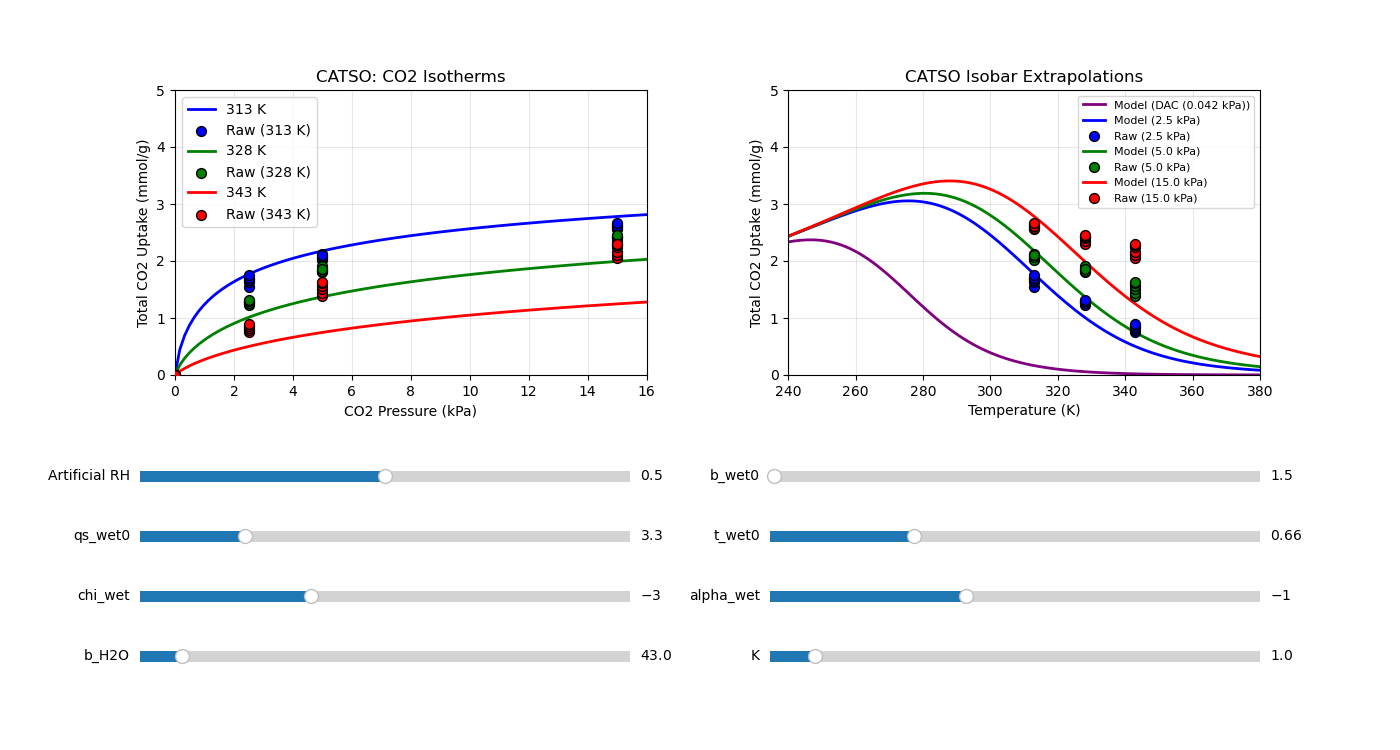

In [42]:
# CATSO 
JL_CATSO = pd.read_csv('JL_co2h2o_pts.csv')
JL_CATSO['P_kPa'] = JL_CATSO['pCO2 (bar)'].values * 100

R = 8.314
T0 = 313
T_values = [313, 328, 343]

# Fixed Dry CO2 Parameters
qs0 = 3.3284
chi = -3.0860
b0 = 76.0440
dH = -53970 
t0 = 0.3436
alpha = -1.2472

# Fixed Enthalpy
dH_wet = -67670

def theta_h2o(K, RH):
    x_h2o_m = 1.0 / np.clip(K, 1e-5, np.inf)
    S = 20.0  
    w = 1.0 / (1.0 + np.exp(-S * (RH - x_h2o_m)))
    return (1.0 - w) * K * RH + w

def catso_total_model(P_co2, T, RH, qs_wet0, b_wet0, t_wet0, chi_wet, alpha_wet, b_h2o_val, K_val):
    # Dry Parameters at T
    qs_dry = qs0 * np.exp(chi * (1.0 - (T / T0)))
    b_dry  = b0 * np.exp((-dH / (R * T0)) * ((T0 / T) - 1.0))
    t_dry  = np.clip(t0 + alpha * (1.0 - (T0 / T)), 1e-5, 10)
    
    # Wet Parameters at T
    qs_wet = qs_wet0 * np.exp(chi_wet * (1.0 - (T / T0)))
    b_wet  = b_wet0 * np.exp((-dH_wet / (R * T0)) * ((T0 / T) - 1.0))
    t_wet  = np.clip(t_wet0 + alpha_wet * (1.0 - (T0 / T)), 1e-5, 10)
    
    # Eq 15 Competitive Adsorption (Dry Sites)
    num_comp = qs_dry * b_dry * P_co2
    den_comp = (1.0 + (b_dry * P_co2)**t_dry + (b_h2o_val * RH)**t_dry) ** (1.0 / t_dry)
    q_comp = num_comp / den_comp
    
    # Calculate Theta switch
    theta_m = theta_h2o(K_val, RH)
    
    # Eq 16 Wet Sites Adsorption
    num_wet = qs_wet * b_wet * P_co2
    den_wet = (1.0 + (b_wet * P_co2)**t_wet) ** (1.0 / t_wet)
    q_wet = theta_m * (num_wet / den_wet)
    
    return q_comp + q_wet

# Initial Parameter Values
init_RH = 0.50
init_qsw = 3.29
init_bw = 1.54
init_tw = 0.66
init_chiw = -3.0
init_alphaw = -1.0
init_bh2o = 43
init_K = 1.0

# Arrays for plotting
P_plot = np.linspace(0, 16, 100) # kPa
T_plot = np.linspace(240, 380, 100) # K

isobar_pressures = [0.042, 2.5, 5.0, 15.0]
isobar_colors = ['purple', 'blue', 'green', 'red']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7.5))
plt.subplots_adjust(bottom=0.50, wspace=0.3)
colors = {T_values[0]: 'blue', T_values[1]: 'green', T_values[2]: 'red'}

# Plot 1: CO2 Isotherms
iso_lines = {}
for T_val in T_values:
    q_pred = catso_total_model(P_plot, T_val, init_RH, init_qsw, init_bw, init_tw, init_chiw, init_alphaw, init_bh2o, init_K)
    line, = ax1.plot(P_plot, q_pred, color=colors[T_val], linewidth=2, label=f'{T_val} K')
    iso_lines[T_val] = line
    
    # Raw Data scatter
    if not JL_CATSO.empty:
        subset = JL_CATSO[JL_CATSO['Temp (K)'] == T_val]
        ax1.scatter(subset['P_kPa'], subset['CO2 Adsorption (mmol/g)'], 
                    color=colors[T_val], s=50, edgecolor='black', zorder=5, label=f'Raw ({T_val} K)')

ax1.set_xlim(0, 16)
ax1.set_ylim(0, 5)
ax1.set_title('CATSO: CO2 Isotherms')
ax1.set_xlabel('CO2 Pressure (kPa)')
ax1.set_ylabel('Total CO2 Uptake (mmol/g)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Isobars
isobar_lines = {}
for i, P_val in enumerate(isobar_pressures):
    c = isobar_colors[i]
    q_iso = catso_total_model(P_val, T_plot, init_RH, init_qsw, init_bw, init_tw, init_chiw, init_alphaw, init_bh2o, init_K)
    label = 'DAC (0.042 kPa)' if P_val == 0.042 else f'{P_val} kPa'
    line, = ax2.plot(T_plot, q_iso, color=c, linewidth=2, label=f'Model ({label})')
    isobar_lines[P_val] = line
    
    if not JL_CATSO.empty and P_val != 0.042:
        subset = JL_CATSO[np.isclose(JL_CATSO['P_kPa'], P_val, atol=0.1)]
        ax2.scatter(subset['Temp (K)'], subset['CO2 Adsorption (mmol/g)'], 
                    color=c, s=50, edgecolor='black', zorder=5, label=f'Raw ({P_val} kPa)')

ax2.set_xlim(240, 380)
ax2.set_ylim(0, 5)
ax2.set_title('CATSO Isobar Extrapolations')
ax2.set_xlabel('Temperature (K)')
ax2.set_ylabel('Total CO2 Uptake (mmol/g)')
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.3)

# Sliders
axcolor = 'lightgoldenrodyellow'

# Column 1
ax_RH     = plt.axes([0.10, 0.35, 0.35, 0.03], facecolor=axcolor)
ax_qsw    = plt.axes([0.10, 0.27, 0.35, 0.03], facecolor=axcolor)
ax_chiw   = plt.axes([0.10, 0.19, 0.35, 0.03], facecolor=axcolor)
ax_bh2o   = plt.axes([0.10, 0.11, 0.35, 0.03], facecolor=axcolor)

# Column 2
ax_bw     = plt.axes([0.55, 0.35, 0.35, 0.03], facecolor=axcolor)
ax_tw     = plt.axes([0.55, 0.27, 0.35, 0.03], facecolor=axcolor)
ax_alphaw = plt.axes([0.55, 0.19, 0.35, 0.03], facecolor=axcolor)
ax_K      = plt.axes([0.55, 0.11, 0.35, 0.03], facecolor=axcolor)

s_RH      = Slider(ax_RH, 'Artificial RH', 0.0, 1.0, valinit=init_RH)
s_qsw     = Slider(ax_qsw, 'qs_wet0', 0.1, 15.0, valinit=init_qsw)
s_chiw    = Slider(ax_chiw, 'chi_wet', -10.0, 10.0, valinit=init_chiw)
s_bh2o    = Slider(ax_bh2o, 'b_H2O', 0.1, 500.0, valinit=init_bh2o)

s_bw      = Slider(ax_bw, 'b_wet0', 0.1, 200.0, valinit=init_bw)
s_tw      = Slider(ax_tw, 't_wet0', 0.1, 2.0, valinit=init_tw)
s_alphaw  = Slider(ax_alphaw, 'alpha_wet', -5.0, 5.0, valinit=init_alphaw)
s_K       = Slider(ax_K, 'K', 0.1, 10.0, valinit=init_K)

# Update Function
def update(val):
    rh = s_RH.val
    qsw = s_qsw.val
    chiw = s_chiw.val
    bh2o = s_bh2o.val
    bw = s_bw.val
    tw = s_tw.val
    alphaw = s_alphaw.val
    kval = s_K.val
    
    for T_val in T_values:
        new_iso = catso_total_model(P_plot, T_val, rh, qsw, bw, tw, chiw, alphaw, bh2o, kval)
        iso_lines[T_val].set_ydata(new_iso)

    for P_val in isobar_pressures:
        new_isobar = catso_total_model(P_val, T_plot, rh, qsw, bw, tw, chiw, alphaw, bh2o, kval)
        isobar_lines[P_val].set_ydata(new_isobar)
        
    fig.canvas.draw_idle()

s_RH.on_changed(update)
s_qsw.on_changed(update)
s_chiw.on_changed(update)
s_bh2o.on_changed(update)
s_bw.on_changed(update)
s_tw.on_changed(update)
s_alphaw.on_changed(update)
s_K.on_changed(update)

plt.show()